# Boltz structure-only TCR–pMHC classifier with TCR-neighbourhood averaging

This notebook implements a Bradley-style structural baseline for your Boltz outputs.

The workflow is:

1. Load train, validation, test and IMMREP multiview CSVs.
2. Retain only full-chain complexes: TCRα, TCRβ, peptide and HLA all present.
3. Resolve each pair's Boltz confidence JSON from the `boltz_embedding_npz` path.
4. Extract global confidence scores and chain-pair ipTM values.
5. Filter to high-confidence structures, by default `confidence_score >= 0.8`.
6. Build a TCR × pMHC score matrix.
7. Define neighbourhoods of similar TCRs using normalised Levenshtein distance on `TCR_full`.
8. Average each TCR's pMHC score vector over its nearest TCR neighbours.
9. Apply two-way matrix correction: `score - TCR_mean - pMHC_mean + global_mean`.
10. Evaluate AUROC and AUPRC on validation, test and IMMREP.
11. Generate diagnostic plots so you can inspect what is driving the result.

The primary structure-only scores to inspect are usually the residual columns ending in:

`_avg_resid_tcr_pmhc`

Those are closest to the Bradley-style transformation: interface score → local TCR-neighbourhood averaging → two-way TCR/pMHC bias correction.

## 0. Optional dependency installation

Run this cell only if your environment is missing the packages. `rapidfuzz` is used for fast Levenshtein distances; if it is not installed, the notebook falls back to a slower pure-Python implementation.

In [1]:
# Uncomment if needed.
# !pip install rapidfuzz pyyaml scikit-learn matplotlib pandas numpy

## 1. Imports and configuration

Adjust the paths only if your files have moved. The default paths match the locations you provided.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import yaml
except Exception:
    yaml = None

try:
    from rapidfuzz.distance import Levenshtein as RFLevenshtein
except Exception:
    RFLevenshtein = None

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 220)

BASE = Path("/home/natasha/multimodal_model")

CSV_PATHS = {
    # Train is intentionally commented out. The train split is positive-only,
    # so it cannot support binary classification metrics such as AUROC/AUC0.1.
    # "train": BASE / "data/train/train_multiview.csv",
    "val": BASE / "data/val/val_multiview.csv",
    "test": BASE / "data/test/test_multiview.csv",
    "immrep": BASE / "data/immrep_test/immrep_test_multiview.csv",
}

OUTDIR = BASE / "scripts/analysis/boltz_structural_neighbour_classifier_notebook"
OUTDIR.mkdir(parents=True, exist_ok=True)

CONFIDENCE_THRESHOLD = 0.80
K_VALUES = [5, 10, 25, 50]
SCORE_COLS = [
    "iptm_tcr_pep_mean",
    "iptm_tcr_pep_max",
    "confidence_score",
    "iptm_global",
    "struct_composite",
]

# Train is excluded by default because it is positive-only and cannot be used for classifier evaluation.
INCLUDE_TRAIN = False

# Recursive fallback search can be slow, but useful if paths are inconsistent.
SEARCH_FALLBACK = True

# Whether to multiply each neighbourhood-averaged vector by sqrt(n_neighbours), as in Bradley's slide.
MULTIPLY_SQRT_N = True

print("Base:", BASE)
print("Output directory:", OUTDIR)
print("rapidfuzz available:", RFLevenshtein is not None)
print("PyYAML available:", yaml is not None)

Base: /home/natasha/multimodal_model
Output directory: /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook
rapidfuzz available: True
PyYAML available: True


## 2. Helper functions

These functions load split CSVs, locate Boltz confidence JSONs, extract structural scores, build TCR neighbourhoods, apply the Bradley-style matrix transformations, and evaluate AUROC/AUPRC.

In [2]:
def first_existing_col(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def normalise_pair_id(pair_id: object) -> str:
    return str(pair_id).strip()


def safe_float(x) -> float:
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def levenshtein_distance_py(a: str, b: str) -> int:
    """Pure-Python fallback if rapidfuzz is unavailable."""
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i]
        for j, cb in enumerate(b, start=1):
            insert = current[j - 1] + 1
            delete = previous[j] + 1
            substitute = previous[j - 1] + (ca != cb)
            current.append(min(insert, delete, substitute))
        previous = current
    return previous[-1]


def norm_lev_distance(a: str, b: str) -> float:
    """Normalised Levenshtein distance in [0, 1]. 0 means identical."""
    a = "" if pd.isna(a) else str(a)
    b = "" if pd.isna(b) else str(b)
    denom = max(len(a), len(b))
    if denom == 0:
        return 0.0
    if RFLevenshtein is not None:
        d = RFLevenshtein.distance(a, b)
    else:
        d = levenshtein_distance_py(a, b)
    return float(d) / float(denom)


def resolve_path_maybe_relative(path_value: object, base: Path) -> Optional[Path]:
    if pd.isna(path_value):
        return None
    p = Path(str(path_value))
    if p.is_absolute():
        return p
    return base / p


def candidate_conf_paths_from_npz(pair_id: str, npz_path: Path) -> List[Path]:
    """Generate likely locations for confidence_<pair_id>_model_0.json."""
    candidates: List[Path] = []
    name = f"confidence_{pair_id}_model_0.json"

    candidates.append(npz_path.with_name(name))
    candidates.append(npz_path.parent / name)

    for parent in list(npz_path.parents)[:5]:
        candidates.append(parent / name)
        candidates.append(parent / "predictions" / pair_id / name)
        candidates.append(parent / "predictions" / name)

    seen = set()
    out = []
    for c in candidates:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out


def find_conf_path(row: pd.Series, base: Path, search_fallback: bool = True) -> Optional[Path]:
    pair_id = normalise_pair_id(row["pair_id"])

    if "conf_path" in row and pd.notna(row["conf_path"]):
        p = resolve_path_maybe_relative(row["conf_path"], base)
        if p is not None and p.exists():
            return p

    if "boltz_embedding_npz" in row and pd.notna(row["boltz_embedding_npz"]):
        npz_path = resolve_path_maybe_relative(row["boltz_embedding_npz"], base)
        if npz_path is not None:
            for c in candidate_conf_paths_from_npz(pair_id, npz_path):
                if c.exists():
                    return c

    if "yaml_path" in row and pd.notna(row["yaml_path"]):
        yp = resolve_path_maybe_relative(row["yaml_path"], base)
        if yp is not None:
            name = f"confidence_{pair_id}_model_0.json"
            for parent in list(yp.parents)[:5]:
                c = parent / name
                if c.exists():
                    return c

    if search_fallback:
        name = f"confidence_{pair_id}_model_0.json"
        likely_roots = [base / "outputs", base / "outputs_data"]
        for root in likely_roots:
            if not root.exists():
                continue
            matches = list(root.rglob(name))
            if matches:
                matches = sorted(matches, key=lambda p: ("/predictions/" not in str(p), len(str(p))))
                return matches[0]

    return None


def read_conf_json(conf_path: Path) -> Dict:
    with conf_path.open("r") as f:
        return json.load(f)


def pair_iptm(conf: Dict, i: int, j: int) -> float:
    """Read pair_chains_iptm robustly for dict-of-dicts or list-of-lists."""
    pci = conf.get("pair_chains_iptm")
    if pci is None:
        return np.nan
    try:
        if isinstance(pci, dict):
            return safe_float(pci[str(i)][str(j)])
        return safe_float(pci[i][j])
    except Exception:
        return np.nan


def resolve_yaml_path(row: pd.Series, base: Path) -> Optional[Path]:
    if "yaml_path" in row and pd.notna(row["yaml_path"]):
        p = resolve_path_maybe_relative(row["yaml_path"], base)
        if p is not None and p.exists():
            return p

    pair_id = normalise_pair_id(row["pair_id"])
    candidates = [
        base / "data/train/_archive_root_yamls" / f"{pair_id}.yaml",
        base / "data/val/_archive_root_yamls" / f"{pair_id}.yaml",
        base / "data/test/_archive_root_yamls" / f"{pair_id}.yaml",
        base / "data/immrep_test/_archive_root_yamls" / f"{pair_id}.yaml",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def chain_names_from_yaml(yaml_path: Path) -> List[str]:
    """Infer chain labels from the Boltz YAML."""
    if yaml is None:
        raise RuntimeError("PyYAML is required to parse YAML files. Install with: pip install pyyaml")

    doc = yaml.safe_load(yaml_path.read_text())
    seqs = doc.get("sequences", [])
    names: List[str] = []

    for seq in seqs:
        protein = seq.get("protein", {}) if isinstance(seq, dict) else {}
        msa = str(protein.get("msa", "")).lower()
        sid = str(protein.get("id", "")).lower()
        joined = f"{msa} {sid}"

        if "tcra" in joined or "tra" in joined or "alpha" in joined:
            names.append("tcra")
        elif "tcrb" in joined or "trb" in joined or "beta" in joined:
            names.append("tcrb")
        elif "mhc" in joined or "hla" in joined:
            names.append("hla")
        else:
            names.append("pep")

    return names


def interface_iptms_from_conf(conf: Dict, yaml_path: Optional[Path]) -> Dict[str, float]:
    out: Dict[str, float] = {}

    out["confidence_score"] = safe_float(conf.get("confidence_score"))
    out["ptm"] = safe_float(conf.get("ptm"))
    out["iptm_global"] = safe_float(conf.get("iptm"))
    out["complex_plddt"] = safe_float(conf.get("complex_plddt"))

    if "pair_chains_iptm" not in conf:
        return out

    if yaml_path is not None and yaml_path.exists():
        try:
            names = chain_names_from_yaml(yaml_path)
        except Exception:
            names = []
    else:
        names = []

    # Fallback order for full-chain complexes.
    if not names or len(names) < 4:
        names = ["tcra", "tcrb", "pep", "hla"]

    idx: Dict[str, int] = {}
    for i, n in enumerate(names):
        idx.setdefault(n, i)

    if "pep" in idx and "hla" in idx:
        out["iptm_pep_hla"] = pair_iptm(conf, idx["pep"], idx["hla"])
    if "tcra" in idx and "pep" in idx:
        out["iptm_tcra_pep"] = pair_iptm(conf, idx["tcra"], idx["pep"])
    if "tcrb" in idx and "pep" in idx:
        out["iptm_tcrb_pep"] = pair_iptm(conf, idx["tcrb"], idx["pep"])
    if "tcra" in idx and "tcrb" in idx:
        out["iptm_tcra_tcrb"] = pair_iptm(conf, idx["tcra"], idx["tcrb"])
    if "tcra" in idx and "hla" in idx:
        out["iptm_tcra_hla"] = pair_iptm(conf, idx["tcra"], idx["hla"])
    if "tcrb" in idx and "hla" in idx:
        out["iptm_tcrb_hla"] = pair_iptm(conf, idx["tcrb"], idx["hla"])

    tcr_pep = [out.get("iptm_tcra_pep", np.nan), out.get("iptm_tcrb_pep", np.nan)]
    tcr_pep = [x for x in tcr_pep if pd.notna(x)]
    if tcr_pep:
        out["iptm_tcr_pep_mean"] = float(np.mean(tcr_pep))
        out["iptm_tcr_pep_max"] = float(np.max(tcr_pep))
        out["iptm_tcr_pep_min"] = float(np.min(tcr_pep))

    tcr_hla = [out.get("iptm_tcra_hla", np.nan), out.get("iptm_tcrb_hla", np.nan)]
    tcr_hla = [x for x in tcr_hla if pd.notna(x)]
    if tcr_hla:
        out["iptm_tcr_hla_mean"] = float(np.mean(tcr_hla))

    if pd.notna(out.get("iptm_tcr_pep_mean", np.nan)):
        out["struct_composite"] = (
            0.60 * out["iptm_tcr_pep_mean"]
            + 0.25 * out.get("iptm_global", np.nan)
            + 0.15 * out.get("confidence_score", np.nan)
        )
    else:
        out["struct_composite"] = np.nan

    return out

In [3]:
def add_boltz_scores(df: pd.DataFrame, base: Path, search_fallback: bool = True) -> pd.DataFrame:
    rows = []
    missing_conf = 0

    for i, row in df.iterrows():
        if i % 1000 == 0 and i > 0:
            print(f"    processed {i:,}/{len(df):,} rows")

        row_dict = row.to_dict()
        conf_path = find_conf_path(row, base=base, search_fallback=search_fallback)
        if conf_path is None or not conf_path.exists():
            missing_conf += 1
            row_dict["conf_path"] = np.nan
            rows.append(row_dict)
            continue

        yaml_path = resolve_yaml_path(row, base=base)
        try:
            conf = read_conf_json(conf_path)
            scores = interface_iptms_from_conf(conf, yaml_path)
        except Exception as e:
            scores = {"score_read_error": repr(e)}

        row_dict["conf_path"] = str(conf_path)
        row_dict["resolved_yaml_path"] = str(yaml_path) if yaml_path is not None else np.nan
        row_dict.update(scores)
        rows.append(row_dict)

    out = pd.DataFrame(rows)
    print(f"  Boltz score merge: rows={len(out):,} | missing_conf={missing_conf:,}")
    return out


def load_split_csv(path: Path, split: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["split"] = split
    if "pair_id" not in df.columns:
        if "immrep_pair_id" in df.columns:
            df = df.rename(columns={"immrep_pair_id": "pair_id"})
        else:
            raise ValueError(f"No pair_id column found in {path}")
    df["pair_id"] = df["pair_id"].map(normalise_pair_id)
    return df


def add_ids(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    tcr_col = first_existing_col(df, ["TCR_full", "tcr_full", "TCR", "tcr"])
    pep_col = first_existing_col(df, ["Peptide", "peptide", "pep"])
    hla_col = first_existing_col(df, ["HLA_sequence", "hla_sequence", "HLA", "hla"])
    label_col = first_existing_col(df, ["binding_flag", "label", "target", "binder", "is_binder"])

    if tcr_col is None:
        raise ValueError("Could not find TCR sequence column. Expected TCR_full or equivalent.")
    if pep_col is None:
        raise ValueError("Could not find peptide column. Expected Peptide or equivalent.")

    df["tcr_id"] = df[tcr_col].fillna("MISSING_TCR").astype(str)
    df["pep_id"] = df[pep_col].fillna("MISSING_PEP").astype(str)
    if hla_col is not None:
        df["pmhc_id"] = df[pep_col].fillna("MISSING_PEP").astype(str) + "|" + df[hla_col].fillna("MISSING_HLA").astype(str)
    else:
        df["pmhc_id"] = df["pep_id"]
    if label_col is not None and label_col != "binding_flag":
        df["binding_flag"] = df[label_col]
    return df


def full_chain_mask(df: pd.DataFrame) -> pd.Series:
    required = ["tcra_len", "tcrb_len", "pep_len", "hla_len"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Required full-chain column missing: {c}")
    return (
        (pd.to_numeric(df["tcra_len"], errors="coerce") > 0)
        & (pd.to_numeric(df["tcrb_len"], errors="coerce") > 0)
        & (pd.to_numeric(df["pep_len"], errors="coerce") > 0)
        & (pd.to_numeric(df["hla_len"], errors="coerce") > 0)
    )


def prepare_split(
    path: Path,
    split: str,
    base: Path,
    confidence_threshold: float,
    search_fallback: bool,
) -> Tuple[pd.DataFrame, Dict[str, int]]:
    print(f"\nLoading {split}: {path}")
    df0 = load_split_csv(path, split)
    n0 = len(df0)

    df = df0.loc[full_chain_mask(df0)].copy()
    n_full = len(df)
    print(f"  Full-chain retained: {n_full:,}/{n0:,}")

    df = add_boltz_scores(df, base=base, search_fallback=search_fallback)
    df = add_ids(df)

    if "confidence_score" not in df.columns:
        raise ValueError("confidence_score was not extracted from Boltz JSON.")

    n_with_conf = int(pd.to_numeric(df["confidence_score"], errors="coerce").notna().sum())
    before_conf = len(df)
    df = df.loc[pd.to_numeric(df["confidence_score"], errors="coerce") >= confidence_threshold].copy()
    after_conf = len(df)
    print(f"  High-confidence retained: {after_conf:,}/{before_conf:,} using confidence_score >= {confidence_threshold}")

    coverage = {
        "split": split,
        "n_raw": n0,
        "n_full_chain": n_full,
        "n_with_conf": n_with_conf,
        "n_high_conf": after_conf,
        "full_chain_coverage": n_full / n0 if n0 else np.nan,
        "conf_coverage_within_full_chain": n_with_conf / n_full if n_full else np.nan,
        "high_conf_coverage_within_full_chain": after_conf / n_full if n_full else np.nan,
        "high_conf_coverage_total": after_conf / n0 if n0 else np.nan,
    }

    if "binding_flag" in df.columns:
        y = pd.to_numeric(df["binding_flag"], errors="coerce")
        coverage["n_pos_high_conf"] = int((y == 1).sum())
        coverage["n_neg_high_conf"] = int((y == 0).sum())

    return df, coverage

In [4]:
def make_score_matrix(df: pd.DataFrame, score_col: str) -> pd.DataFrame:
    return df.pivot_table(index="tcr_id", columns="pmhc_id", values=score_col, aggfunc="mean")


def build_knn_neighbourhoods(tcr_sequences: pd.Series, k: int, include_self: bool = True) -> Dict[str, List[str]]:
    tcr_sequences = tcr_sequences.dropna().drop_duplicates()
    ids = list(tcr_sequences.index)
    seqs = tcr_sequences.to_dict()
    n = len(ids)
    if n == 0:
        return {}

    k_eff = min(k, n if include_self else max(n - 1, 1))
    neighbourhoods: Dict[str, List[str]] = {}

    for tid_i in ids:
        dists: List[Tuple[str, float]] = []
        for tid_j in ids:
            if not include_self and tid_i == tid_j:
                continue
            d = norm_lev_distance(seqs[tid_i], seqs[tid_j])
            dists.append((tid_j, d))
        dists.sort(key=lambda x: (x[1], x[0]))
        neighbourhoods[tid_i] = [tid for tid, _ in dists[:k_eff]]

    return neighbourhoods


def build_radius_neighbourhoods(
    tcr_sequences: pd.Series,
    max_distance: float,
    min_neighbours: int,
    include_self: bool = True,
) -> Dict[str, List[str]]:
    tcr_sequences = tcr_sequences.dropna().drop_duplicates()
    ids = list(tcr_sequences.index)
    seqs = tcr_sequences.to_dict()
    neighbourhoods: Dict[str, List[str]] = {}

    for tid_i in ids:
        within = []
        all_dists = []
        for tid_j in ids:
            if not include_self and tid_i == tid_j:
                continue
            d = norm_lev_distance(seqs[tid_i], seqs[tid_j])
            all_dists.append((tid_j, d))
            if d <= max_distance:
                within.append(tid_j)
        if len(within) < min_neighbours:
            all_dists.sort(key=lambda x: (x[1], x[0]))
            within = [tid for tid, _ in all_dists[: min(min_neighbours, len(all_dists))]]
        neighbourhoods[tid_i] = within

    return neighbourhoods


def neighbourhood_average_matrix(
    mat: pd.DataFrame,
    neighbourhoods: Dict[str, List[str]],
    multiply_sqrt_n: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    avg = pd.DataFrame(index=mat.index, columns=mat.columns, dtype=float)
    info_rows = []

    for tid in mat.index:
        neigh = [n for n in neighbourhoods.get(tid, [tid]) if n in mat.index]
        if not neigh:
            neigh = [tid]
        sub = mat.loc[neigh]
        vec = sub.mean(axis=0, skipna=True)
        if multiply_sqrt_n:
            vec = vec * math.sqrt(len(neigh))
        avg.loc[tid] = vec
        info_rows.append({"tcr_id": tid, "n_neighbours": len(neigh), "neighbours": ";".join(neigh)})

    return avg, pd.DataFrame(info_rows)


def map_matrix_back(df: pd.DataFrame, mat: pd.DataFrame, output_col: str) -> pd.DataFrame:
    df = df.copy()
    row_index = mat.index
    col_index = mat.columns
    vals = []
    for _, r in df.iterrows():
        tid = r["tcr_id"]
        pid = r["pmhc_id"]
        if tid in row_index and pid in col_index:
            vals.append(mat.loc[tid, pid])
        else:
            vals.append(np.nan)
    df[output_col] = vals
    return df


def two_way_bias_correct(df: pd.DataFrame, score_col: str, row_col: str = "tcr_id", col_col: str = "pmhc_id") -> pd.Series:
    x = pd.to_numeric(df[score_col], errors="coerce")
    valid = x.notna()
    out = pd.Series(index=df.index, dtype=float)
    if valid.sum() == 0:
        return out

    g = df.loc[valid]
    xx = x.loc[valid]
    grand = xx.mean()
    row_mean = xx.groupby(g[row_col]).mean()
    col_mean = xx.groupby(g[col_col]).mean()
    out.loc[g.index] = xx - g[row_col].map(row_mean) - g[col_col].map(col_mean) + grand
    return out


def minmax_scale(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    mn = x.min()
    mx = x.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.nan, index=s.index)
    return (x - mn) / (mx - mn)


def add_bradley_scores_for_split(
    df: pd.DataFrame,
    score_cols: Sequence[str],
    k_values: Sequence[int],
    multiply_sqrt_n: bool,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    tcr_sequences = df[["tcr_id", "TCR_full"]].drop_duplicates("tcr_id").set_index("tcr_id")["TCR_full"]

    all_neighbour_info = []

    for k in k_values:
        print(f"  Building TCR neighbourhoods: k={k} | n_tcr={len(tcr_sequences):,}")
        neigh = build_knn_neighbourhoods(tcr_sequences, k=k, include_self=True)
        neighbourhood_label = f"knn{k}"

        for score_col in score_cols:
            if score_col not in df.columns:
                continue
            mat = make_score_matrix(df, score_col)
            avg_mat, neigh_info = neighbourhood_average_matrix(mat, neigh, multiply_sqrt_n=multiply_sqrt_n)
            neigh_info.insert(0, "split", df["split"].iloc[0] if len(df) else "unknown")
            neigh_info.insert(1, "neighbourhood", neighbourhood_label)
            neigh_info.insert(2, "base_score", score_col)
            all_neighbour_info.append(neigh_info)

            avg_col = f"{score_col}_{neighbourhood_label}_avg"
            resid_col = f"{avg_col}_resid_tcr_pmhc"
            scaled_col = f"{resid_col}_scaled01"

            df = map_matrix_back(df, avg_mat, avg_col)
            df[resid_col] = two_way_bias_correct(df, avg_col, row_col="tcr_id", col_col="pmhc_id")
            df[scaled_col] = minmax_scale(df[resid_col])

    neigh_df = pd.concat(all_neighbour_info, ignore_index=True) if all_neighbour_info else pd.DataFrame()
    return df, neigh_df

In [5]:
def evaluate_split_scores(df: pd.DataFrame, score_cols: Sequence[str]) -> pd.DataFrame:
    if "binding_flag" not in df.columns:
        return pd.DataFrame()

    rows = []
    split = df["split"].iloc[0] if len(df) else "unknown"
    y_all = pd.to_numeric(df["binding_flag"], errors="coerce")

    for col in score_cols:
        if col not in df.columns:
            continue
        x_all = pd.to_numeric(df[col], errors="coerce")
        valid = x_all.notna() & y_all.notna()
        if valid.sum() < 2:
            continue
        y = y_all.loc[valid].astype(int)
        x = x_all.loc[valid].astype(float)
        if y.nunique() < 2:
            continue
        rows.append({
            "split": split,
            "score_col": col,
            "n": int(valid.sum()),
            "n_pos": int((y == 1).sum()),
            "n_neg": int((y == 0).sum()),
            "pos_mean": float(x[y == 1].mean()),
            "neg_mean": float(x[y == 0].mean()),
            "pos_median": float(x[y == 1].median()),
            "neg_median": float(x[y == 0].median()),
            "auroc_pos_high": float(roc_auc_score(y, x)),
            "auprc_pos_high": float(average_precision_score(y, x)),
        })

    return pd.DataFrame(rows)


def fit_val_logreg_and_eval(df_all: pd.DataFrame, feature_cols: Sequence[str]) -> pd.DataFrame:
    if "binding_flag" not in df_all.columns:
        return pd.DataFrame()
    if "val" not in set(df_all["split"]):
        print("[WARN] No val split found; skipping logistic regression.")
        return pd.DataFrame()

    train = df_all[df_all["split"] == "val"].copy()
    y_train = pd.to_numeric(train["binding_flag"], errors="coerce")
    X_train = train[list(feature_cols)].apply(pd.to_numeric, errors="coerce")
    valid_train = y_train.notna() & X_train.notna().all(axis=1)
    if valid_train.sum() < 10 or y_train.loc[valid_train].nunique() < 2:
        print("[WARN] Not enough labelled validation rows for logistic regression.")
        return pd.DataFrame()

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, solver="liblinear"),
    )
    clf.fit(X_train.loc[valid_train], y_train.loc[valid_train].astype(int))

    rows = []
    for split, g in df_all.groupby("split"):
        y = pd.to_numeric(g["binding_flag"], errors="coerce")
        X = g[list(feature_cols)].apply(pd.to_numeric, errors="coerce")
        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < 2 or y.loc[valid].nunique() < 2:
            continue
        pred = clf.predict_proba(X.loc[valid])[:, 1]
        yy = y.loc[valid].astype(int)
        rows.append({
            "split": split,
            "score_col": "val_calibrated_logreg",
            "features": ";".join(feature_cols),
            "n": int(valid.sum()),
            "n_pos": int((yy == 1).sum()),
            "n_neg": int((yy == 0).sum()),
            "auroc_pos_high": float(roc_auc_score(yy, pred)),
            "auprc_pos_high": float(average_precision_score(yy, pred)),
        })
    return pd.DataFrame(rows)

## 2b. IMMREP-compatible Macro AUC0.1 helpers

These cells compute McClish-standardised partial AUROC up to `FPR = 0.1`, then macro-average across peptides. This is the benchmark-comparable IMMREP metric.

In [6]:
def safe_mcclish_auc01(y_true, y_score, max_fpr: float = 0.1) -> float:
    """
    Compute McClish-standardised partial AUROC up to max_fpr.

    sklearn.metrics.roc_auc_score(..., max_fpr=0.1) applies the McClish
    standardisation used for partial AUC comparisons: random ranking maps to
    0.5 and perfect ranking maps to 1.0.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    valid = np.isfinite(y_score)
    y_true = y_true[valid]
    y_score = y_score[valid]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, y_score, max_fpr=max_fpr))


def macro_mcclish_auc01_by_peptide(
    df: pd.DataFrame,
    score_col: str,
    label_col: str = "binding_flag",
    peptide_col: str = "Peptide",
    max_fpr: float = 0.1,
) -> Tuple[dict, pd.DataFrame]:
    """
    IMMREP-style Macro AUC0.1.

    For each peptide:
      1. calculate McClish-standardised partial AUROC up to FPR=max_fpr;
      2. exclude peptide groups with only positives or only negatives;
      3. macro-average peptide-level scores arithmetically.
    """
    rows = []

    for peptide, g in df.groupby(peptide_col, dropna=False):
        d = g[[label_col, score_col]].copy()
        d[label_col] = pd.to_numeric(d[label_col], errors="coerce")
        d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
        d = d.dropna()

        n = len(d)
        n_pos = int((d[label_col].astype(int) == 1).sum()) if n else 0
        n_neg = int((d[label_col].astype(int) == 0).sum()) if n else 0

        if n_pos == 0 or n_neg == 0:
            auc01 = np.nan
            evaluable = False
        else:
            auc01 = safe_mcclish_auc01(
                y_true=d[label_col].astype(int).values,
                y_score=d[score_col].astype(float).values,
                max_fpr=max_fpr,
            )
            evaluable = True

        rows.append({
            "peptide": peptide,
            "score_col": score_col,
            "n": n,
            "n_pos": n_pos,
            "n_neg": n_neg,
            "evaluable": evaluable,
            "mcclish_auc01": auc01,
        })

    peptide_auc = pd.DataFrame(rows)
    evaluable_scores = peptide_auc.loc[peptide_auc["evaluable"], "mcclish_auc01"]

    summary = {
        "score_col": score_col,
        "n_rows": int(len(df)),
        "n_peptides_total": int(peptide_auc["peptide"].nunique()),
        "n_peptides_evaluable": int(peptide_auc["evaluable"].sum()),
        "macro_mcclish_auc01": float(evaluable_scores.mean()) if len(evaluable_scores) else np.nan,
        "max_fpr": max_fpr,
    }

    return summary, peptide_auc


def evaluate_macro_mcclish_auc01_all_splits(
    df: pd.DataFrame,
    score_cols: Sequence[str],
    split_col: str = "split",
    label_col: str = "binding_flag",
    peptide_col: str = "Peptide",
    max_fpr: float = 0.1,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Compute Macro AUC0.1 for each split and score column."""
    rows = []
    peptide_tables = []

    for split, split_df in df.groupby(split_col, sort=False):
        for score_col in score_cols:
            if score_col not in split_df.columns:
                continue

            summary, peptide_auc = macro_mcclish_auc01_by_peptide(
                df=split_df,
                score_col=score_col,
                label_col=label_col,
                peptide_col=peptide_col,
                max_fpr=max_fpr,
            )

            summary["split"] = split
            rows.append(summary)

            peptide_auc["split"] = split
            peptide_tables.append(peptide_auc)

    summary_df = pd.DataFrame(rows)
    peptide_df = pd.concat(peptide_tables, ignore_index=True) if peptide_tables else pd.DataFrame()

    if len(summary_df):
        summary_df = summary_df[
            [
                "split",
                "score_col",
                "n_rows",
                "n_peptides_total",
                "n_peptides_evaluable",
                "macro_mcclish_auc01",
                "max_fpr",
            ]
        ].sort_values(["split", "macro_mcclish_auc01"], ascending=[True, False])

    return summary_df, peptide_df


## 3. Quick pre-flight check

This checks that the CSV files exist and shows the columns in each split before doing any heavy processing.

In [7]:
for split, path in CSV_PATHS.items():
    if split == "train" and not INCLUDE_TRAIN:
        continue
    print("", split, path)
    print("exists:", path.exists())
    if path.exists():
        tmp = pd.read_csv(path, nrows=5)
        print("shape preview:", tmp.shape)
        print("columns:", list(tmp.columns))
        display(tmp.head(2))

 val /home/natasha/multimodal_model/data/val/val_multiview.csv
exists: True
shape preview: (5, 17)
columns: ['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'decoy_type', 'source_pair_id', 'donor_pair_id', 'donor_peptide', 'donor_hla_sequence', 'original_pair_id', 'yaml_path', 'pep_len', 'tcra_len', 'tcrb_len', 'hla_len', 'boltz_embedding_npz']


,pair_id,Peptide,HLA_sequence,TCR_full,binding_flag,decoy_type,source_pair_id,donor_pair_id,donor_peptide,donor_hla_sequence,original_pair_id,yaml_path,pep_len,tcra_len,tcrb_len,hla_len,boltz_embedding_npz
0,pair_000,ASFRPELAEFW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYWDGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHNQYAYDGKDYIALNEDLSS...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLLTYIFSNMDMKQDQRLTVLLNKKDKHLSLRIADTQTGDSAIYFCAVSGGYQKVTFGIGTKLQVIPNDGGITQSPKYLFRKEGQNVTLSCEQNLNHDAMYWYRQDPGQGLRL...,1,positive_observed,pair_000,NaN,NaN,NaN,pair_000,data/val/_archive_root_yamls/pair_000.yaml,11,111,111,362,outputs/val/chunk_000/boltz_results_pair_000/predictions/pair_000/embeddings_pair_000.npz
1,pair_001,ASFSPELRMAW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYWDGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHNQYAYDGKDYIALNEDLSS...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLLTYIFSNMDMKQDQRLTVLLNKKDKHLSLRIADTQTGDSAIYFCAVSGGYQKVTFGIGTKLQVIPNDGGITQSPKYLFRKEGQNVTLSCEQNLNHDAMYWYRQDPGQGLRL...,1,positive_observed,pair_001,NaN,NaN,NaN,pair_001,data/val/_archive_root_yamls/pair_001.yaml,11,111,111,362,outputs/val/chunk_000/boltz_results_pair_001/predictions/pair_001/embeddings_pair_001.npz


 test /home/natasha/multimodal_model/data/test/test_multiview.csv
exists: True
shape preview: (5, 17)
columns: ['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'decoy_type', 'source_pair_id', 'donor_pair_id', 'donor_peptide', 'donor_hla_sequence', 'original_pair_id', 'yaml_path', 'pep_len', 'tcra_len', 'tcrb_len', 'hla_len', 'boltz_embedding_npz']


,pair_id,Peptide,HLA_sequence,TCR_full,binding_flag,decoy_type,source_pair_id,donor_pair_id,donor_peptide,donor_hla_sequence,original_pair_id,yaml_path,pep_len,tcra_len,tcrb_len,hla_len,boltz_embedding_npz
0,pair_000,TSTLQEQIGW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYWDGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHDQSAYDGKDYIALNEDLSS...,GNSVTQMEGPVTLSEEAFLTINCTYTATGYPSLFWYVQYPGEGLQLLLKATKADDKGSNKGFEATYRKETTSFHLEKGSVQVSDSAVYFCALNTGFQKLVFGTGTRLLVSPNEAGVTQFPSHSVIEKGQTVTLRCDPISGHDNLYWYRRVMGKEIK...,1,positive_observed,pair_000,NaN,NaN,NaN,pair_000,data/test/_archive_root_yamls/pair_000.yaml,10,112,117,362,outputs/test/chunk_000/boltz_results_pair_000/predictions/pair_000/embeddings_pair_000.npz
1,pair_001,GSLSPELRPIF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYWDGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHDQSAYDGKDYIALNEDLSS...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLLTYIFSNMDMKQDQRLTVLLNKKDKHLSLRIADTQTGDSAIYFCAVSGGYQKVTFGIGTKLQVIPNDGGITQSPKYLFRKEGQNVTLSCEQNLNHDAMYWYRQDPGQGLRL...,1,positive_observed,pair_001,NaN,NaN,NaN,pair_001,data/test/_archive_root_yamls/pair_001.yaml,11,111,111,362,outputs/test/chunk_000/boltz_results_pair_001/predictions/pair_001/embeddings_pair_001.npz


 immrep /home/natasha/multimodal_model/data/immrep_test/immrep_test_multiview.csv
exists: True
shape preview: (5, 11)
columns: ['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'yaml_path', 'pep_len', 'tcra_len', 'tcrb_len', 'hla_len', 'boltz_embedding_npz']


,pair_id,Peptide,HLA_sequence,TCR_full,binding_flag,yaml_path,pep_len,tcra_len,tcrb_len,hla_len,boltz_embedding_npz
0,immrep_pair_00000,MENWSALEL,MRVTAPRTVLLLLSAALALTETWAGSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYWDRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHNQYAYDGKDYIALNEDLRS...,AQSVTQPDIHITVSEGASLELRCNYSYGATPYLFWYVQSPGQGLQLLLKYFSGDTLVQGIKGFEAEFKRSQSSFNLRKPSVHWSDAAEYFCAVGAGNNAGNMLTFGGGTRLMVKPGAGVSQSPRYKVTKRGQDVALRCDPISGHVSLYWYRQALGQ...,1,data/immrep_test/_archive_root_yamls/immrep_pair_00000.yaml,9,115,118,362,outputs_data/immrep_test/chunk_000/boltz_results_immrep_pair_00000/predictions/immrep_pair_00000/embeddings_immrep_pair_00000.npz
1,immrep_pair_00001,TVYPYGTSL,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRS...,GIQVEQSPPDLILQEGANSTLRCNFSDSVNNLQWFHQNPWGQLINLFYIPSGTKQNGRLSATTVATERYSLLYISSSQTTDSGVYFCAVESENNAGNMLTFGGGTRLMVKPDAGVIQSPRHEVTEMGQEVTLRCKPISGHNSLFWYRQTMMRGLEL...,1,data/immrep_test/_archive_root_yamls/immrep_pair_00001.yaml,9,111,117,365,outputs_data/immrep_test/chunk_000/boltz_results_immrep_pair_00001/predictions/immrep_pair_00001/embeddings_immrep_pair_00001.npz


## 4. Load splits, extract Boltz scores and apply the high-confidence filter

This is the slowest step because it reads Boltz confidence JSONs. If path resolution is slow, set `SEARCH_FALLBACK = False` in the configuration cell and rerun. The notebook saves the extracted high-confidence dataframe to disk after this step.

In [8]:
raw_scored_path = OUTDIR / "boltz_structural_high_conf_raw_scores.csv"
coverage_path = OUTDIR / "boltz_structural_neighbour_coverage.csv"

if raw_scored_path.exists() and coverage_path.exists():
    print("Loading cached raw scored dataframe and coverage table...")
    raw_scored_df = pd.read_csv(raw_scored_path)
    coverage_df = pd.read_csv(coverage_path)
else:
    split_paths = dict(CSV_PATHS)
    if not INCLUDE_TRAIN:
        split_paths.pop("train", None)

    split_frames = []
    coverage_rows = []

    for split, path in split_paths.items():
        if not path.exists():
            print(f"[SKIP] Missing {split}: {path}")
            continue

        df_split, coverage = prepare_split(
            path=path,
            split=split,
            base=BASE,
            confidence_threshold=CONFIDENCE_THRESHOLD,
            search_fallback=SEARCH_FALLBACK,
        )
        split_frames.append(df_split)
        coverage_rows.append(coverage)

    raw_scored_df = pd.concat(split_frames, ignore_index=True) if split_frames else pd.DataFrame()
    coverage_df = pd.DataFrame(coverage_rows)

    raw_scored_df.to_csv(raw_scored_path, index=False)
    coverage_df.to_csv(coverage_path, index=False)
    print("Saved:", raw_scored_path)
    print("Saved:", coverage_path)

display(coverage_df)
print("raw_scored_df shape:", raw_scored_df.shape)
print("splits in raw_scored_df:", sorted(raw_scored_df["split"].unique()) if "split" in raw_scored_df.columns and len(raw_scored_df) else [])


Loading cached raw scored dataframe and coverage table...


,split,n_raw,n_full_chain,n_with_conf,n_high_conf,full_chain_coverage,conf_coverage_within_full_chain,high_conf_coverage_within_full_chain,high_conf_coverage_total,n_pos_high_conf,n_neg_high_conf
0,val,3888,3303,3303,2792,0.849537,1.0,0.845292,0.718107,1394,1398
1,test,4364,3795,3795,3223,0.869615,1.0,0.849275,0.738543,1603,1620
2,immrep,10000,10000,10000,9492,1.000000,1.0,0.949200,0.949200,960,8532


raw_scored_df shape: (15507, 38)
splits in raw_scored_df: ['immrep', 'test', 'val']


## 5. Coverage diagnostics

These plots show how much of each split survives the full-chain and high-confidence filters. This matters because a strong AUC on a small retained subset is a narrower claim than strong AUC on most of the dataset.

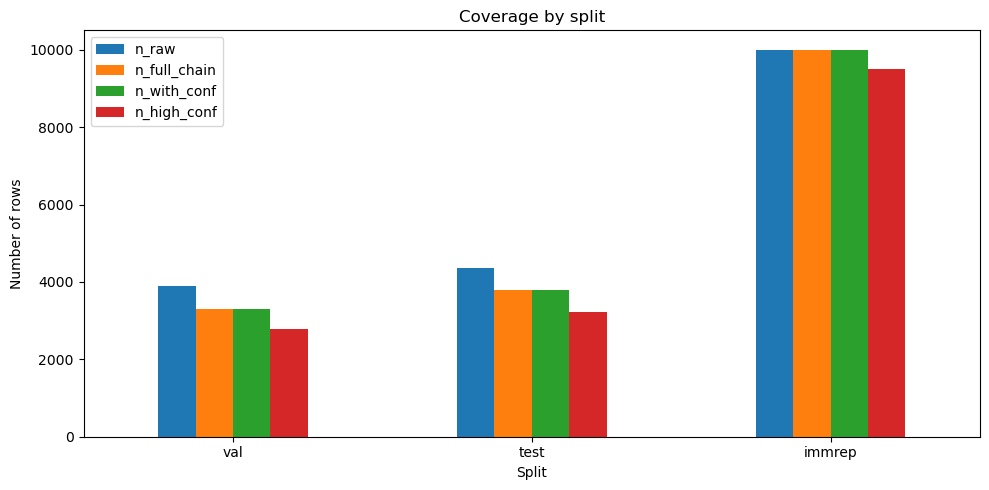

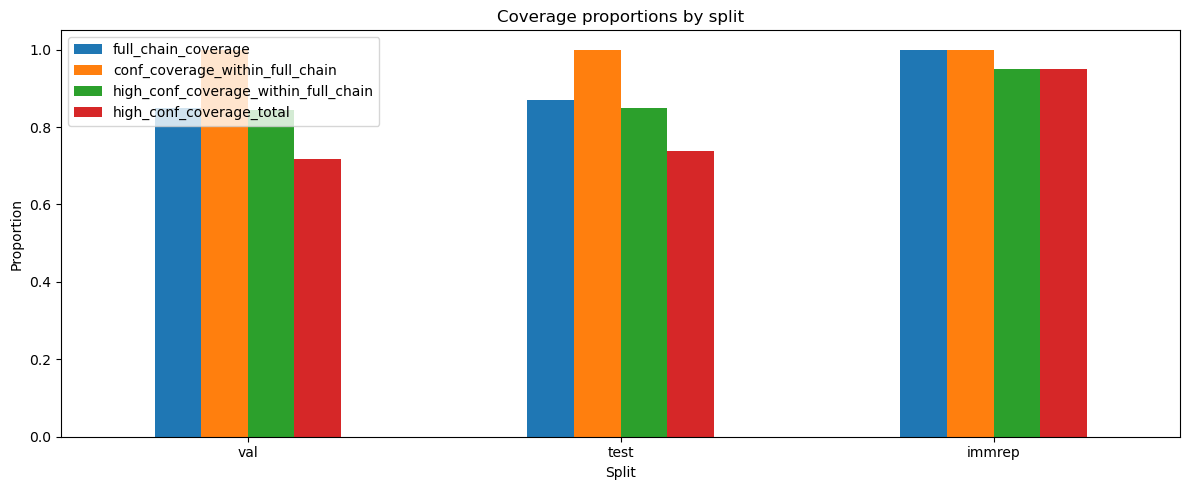

In [9]:
if len(coverage_df):
    ax = coverage_df.set_index("split")[["n_raw", "n_full_chain", "n_with_conf", "n_high_conf"]].plot(kind="bar", figsize=(10, 5))
    ax.set_title("Coverage by split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Number of rows")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    cols = ["full_chain_coverage", "conf_coverage_within_full_chain", "high_conf_coverage_within_full_chain", "high_conf_coverage_total"]
    ax = coverage_df.set_index("split")[cols].plot(kind="bar", figsize=(12, 5))
    ax.set_title("Coverage proportions by split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Inspect extracted structural score distributions

Use this section to sanity-check whether positives and negatives have different score distributions before any TCR-neighbourhood averaging. It is useful for identifying whether the signal is driven by global confidence, interface ipTM, or another metric.

In [10]:
score_cols_available = [c for c in SCORE_COLS if c in raw_scored_df.columns]
print("Available score columns:", score_cols_available)

display(raw_scored_df[["split", "pair_id", "binding_flag", "confidence_score", "iptm_global", "iptm_tcr_pep_mean", "iptm_tcr_pep_max", "struct_composite"]].head())

summary_cols = ["split", "binding_flag"] + score_cols_available
score_summary = raw_scored_df[summary_cols].groupby(["split", "binding_flag"]).agg(["count", "mean", "median", "std"])
display(score_summary)

Available score columns: ['iptm_tcr_pep_mean', 'iptm_tcr_pep_max', 'confidence_score', 'iptm_global', 'struct_composite']


,split,pair_id,binding_flag,confidence_score,iptm_global,iptm_tcr_pep_mean,iptm_tcr_pep_max,struct_composite
0,val,pair_000,1,0.880369,0.970229,0.956945,0.962046,0.948780
1,val,pair_001,1,0.881207,0.970586,0.953134,0.960341,0.946708
2,val,pair_002,1,0.889970,0.967311,0.948972,0.951008,0.944707
3,val,pair_003,1,0.887381,0.970407,0.951134,0.956006,0.946389
4,val,pair_004,1,0.875878,0.949683,0.919223,0.928627,0.920336


iptm_tcr_pep_mean                               iptm_tcr_pep_max                               confidence_score                               iptm_global                                \
                                count      mean    median       std            count      mean    median       std            count      mean    median       std       count      mean    median       std   
split  binding_flag                                                                                                                                                                                           
immrep 0                         8532  0.865092  0.897212  0.091949             8532  0.872146  0.903744  0.089550             8532  0.857552  0.861928  0.020412        8532  0.899671  0.925774  0.069412   
       1                          960  0.874665  0.902721  0.083057              960  0.881554  0.908391  0.080606              960  0.859750  0.863713  0.019035         960  0.906652  0.930114  0.064898   
test   0                         1620  0.822828  0.860655  0.118476             1620  0.831905  0.869313  0.115387             1620  0.850112  0.851699  0.024819        1620  0.868866  0.894671  0.085082   
       1                         1603  0.824642  0.860811  0.118175             1603  0.835573  0.871347  0.114669             1603  0.848842  0.850745  0.024553        1603  0.869898  0.894799  0.084671   
val    0                         1398  0.836242  0.870981  0.108662             1398  0.845692  0.880289  0.105324             1398  0.852392  0.855473  0.025341        1398  0.878089  0.902985  0.080913   
       1                         1394  0.823474  0.860533  0.120165             1394  0.834321  0.872706  0.116818             1394  0.848712  0.851095  0.024775        1394  0.868455  0.894680  0.086548   

                    struct_composite                                
                               count      mean    median       std  
split  binding_flag                                                 
immrep 0                        8532  0.872606  0.899322  0.074784  
       1                         960  0.880424  0.903580  0.068170  
test   0                        1620  0.838430  0.868927  0.095038  
       1                        1603  0.839586  0.868355  0.094751  
val    0                        1398  0.849126  0.876874  0.088276  
       1                        1394  0.838505  0.868053  0.096487

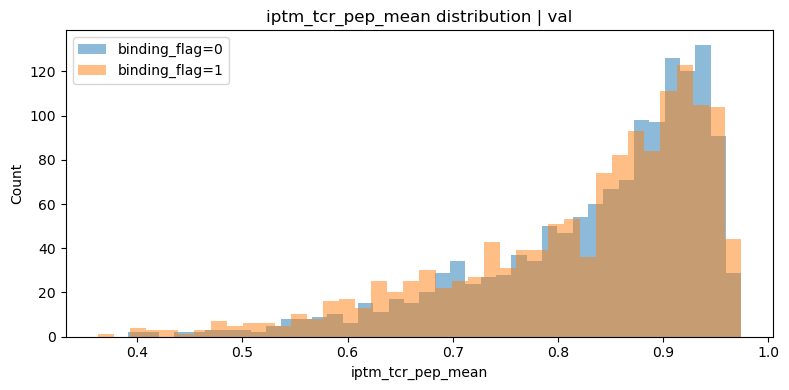

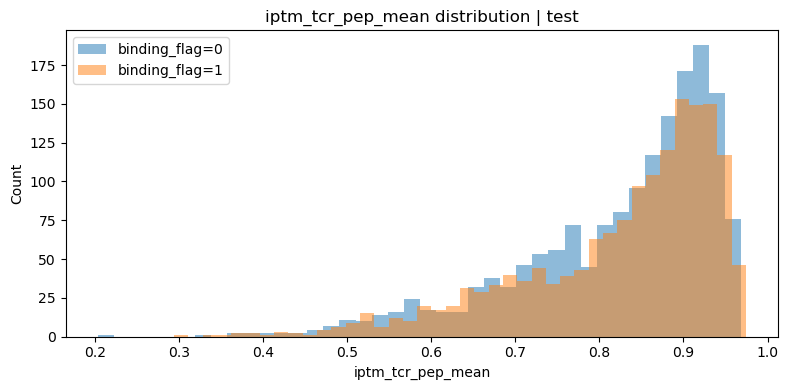

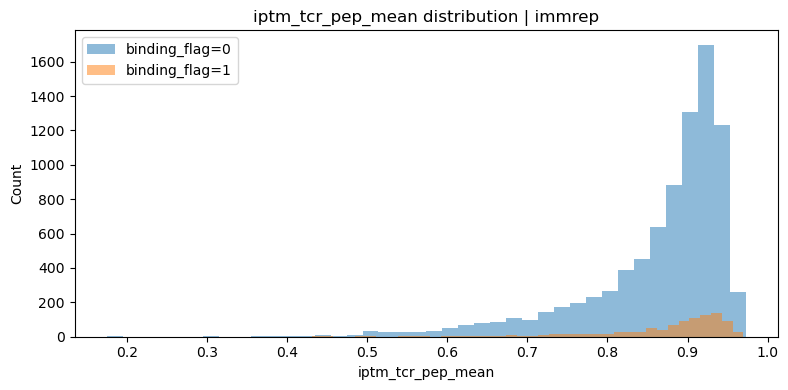

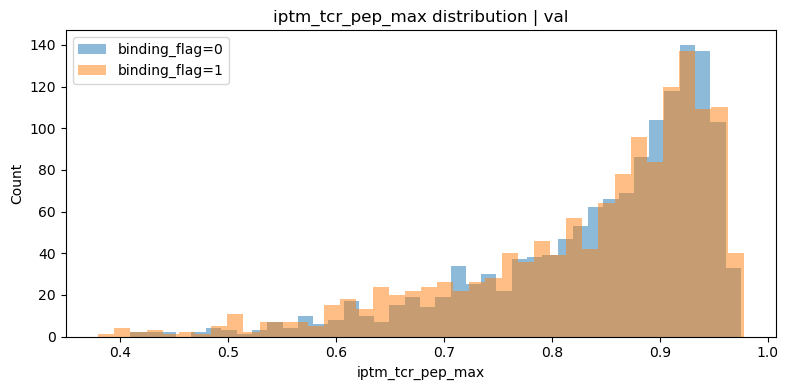

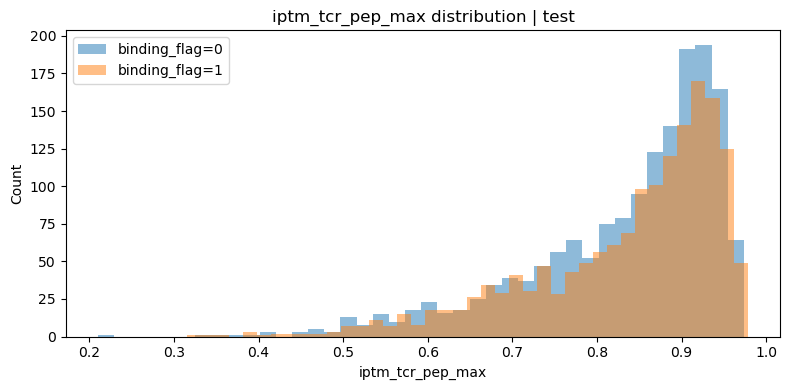

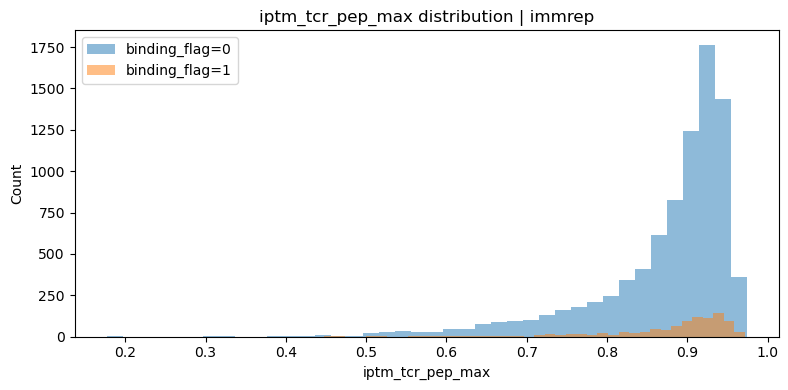

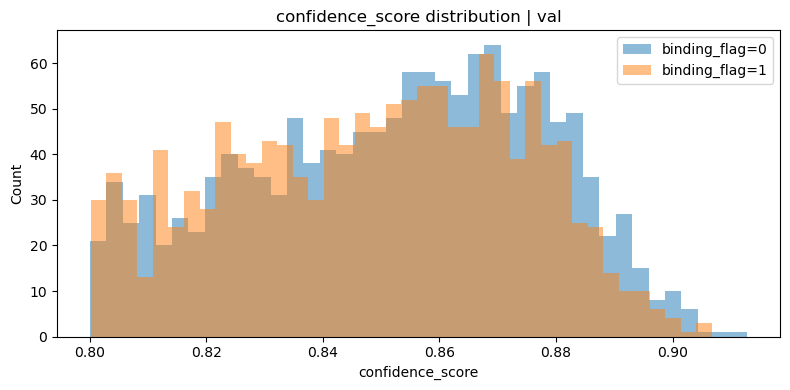

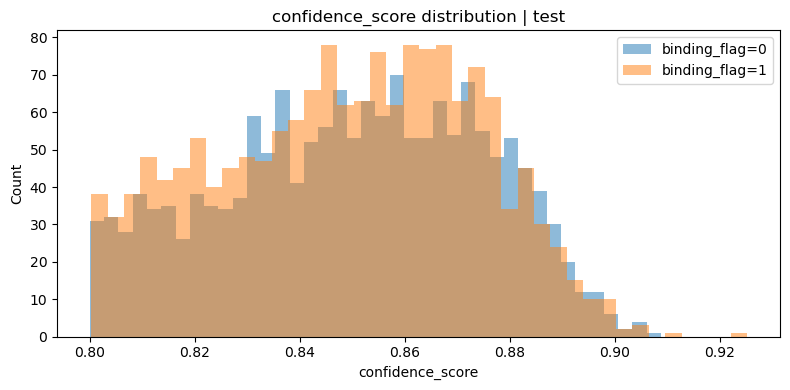

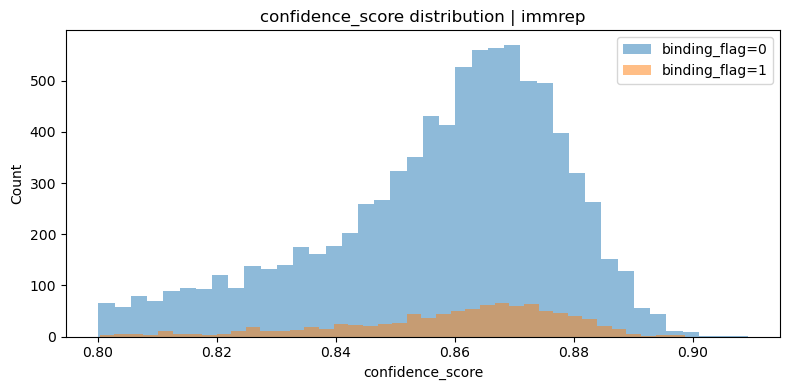

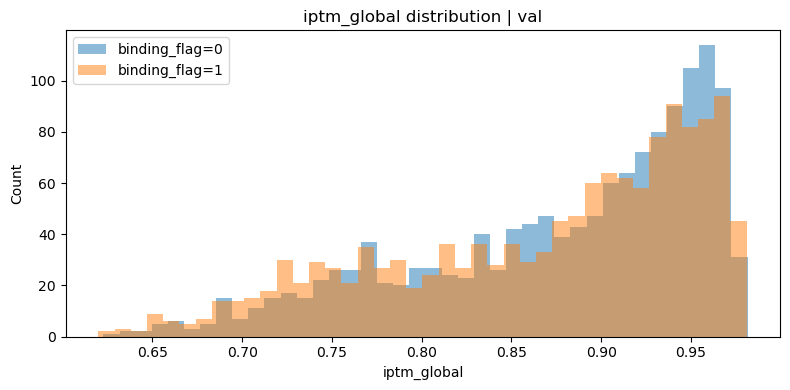

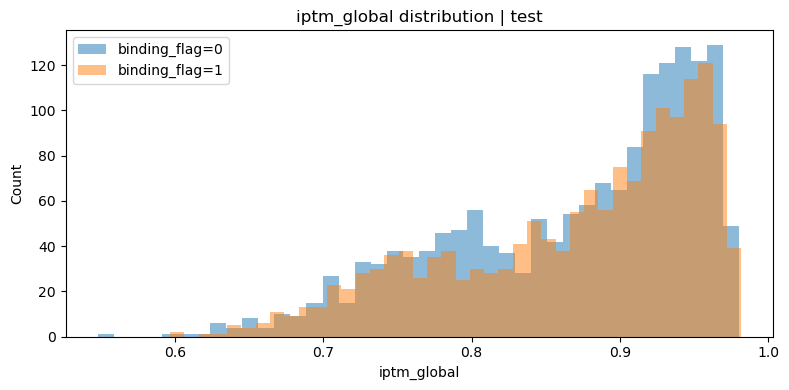

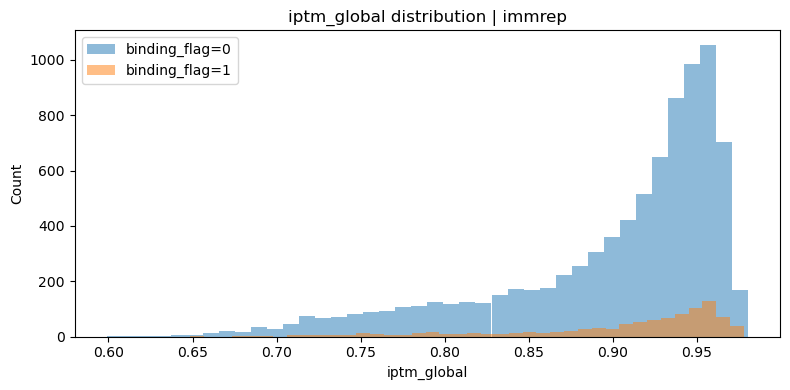

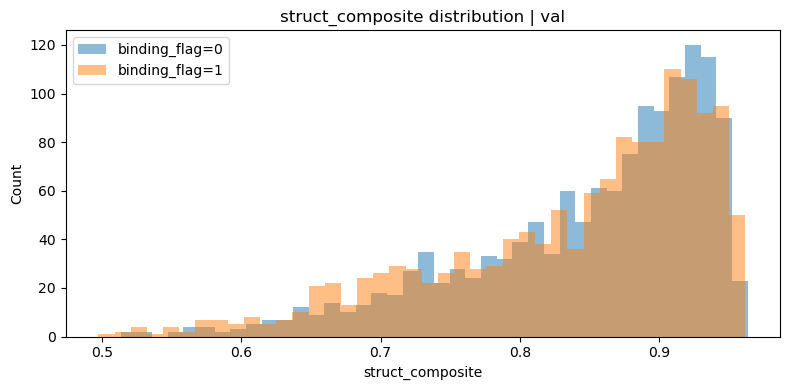

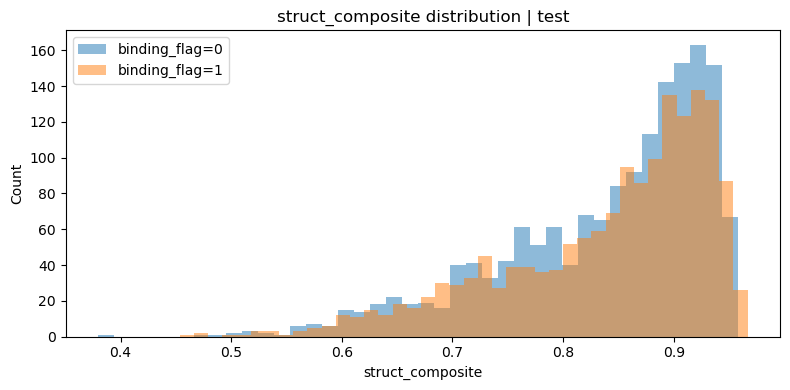

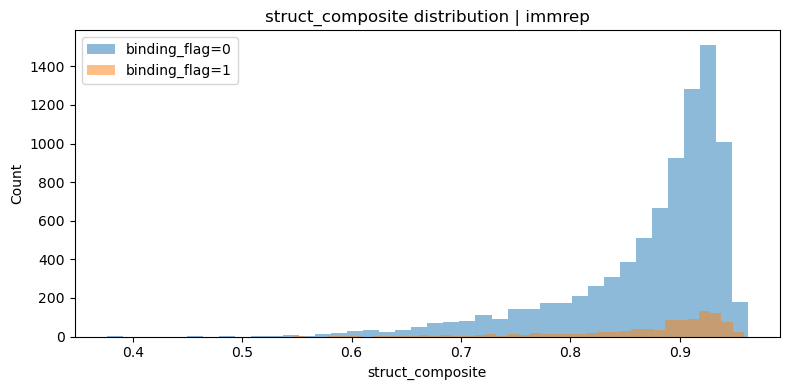

In [11]:
def plot_score_histograms(df: pd.DataFrame, score_col: str):
    if score_col not in df.columns or "binding_flag" not in df.columns:
        print(f"Cannot plot {score_col}")
        return
    splits = [s for s in ["val", "test", "immrep", "train"] if s in set(df["split"])]
    for split in splits:
        g = df[df["split"] == split]
        if g.empty:
            continue
        plt.figure(figsize=(8, 4))
        for label in sorted(pd.to_numeric(g["binding_flag"], errors="coerce").dropna().unique()):
            vals = pd.to_numeric(g.loc[pd.to_numeric(g["binding_flag"], errors="coerce") == label, score_col], errors="coerce").dropna()
            if len(vals):
                plt.hist(vals, bins=40, alpha=0.5, label=f"binding_flag={int(label)}")
        plt.title(f"{score_col} distribution | {split}")
        plt.xlabel(score_col)
        plt.ylabel("Count")
        plt.legend()
        plt.tight_layout()
        plt.show()

for col in score_cols_available:
    plot_score_histograms(raw_scored_df, col)

## 7. Run Bradley-style TCR-neighbourhood averaging and two-way correction

This builds one transformed score per base metric and per `k` value. For example:

`iptm_tcr_pep_mean_knn25_avg_resid_tcr_pmhc`

means:

`iptm_tcr_pep_mean` → average over 25 nearest TCR neighbours → two-way TCR/pMHC residual correction.

In [21]:
processed_splits = []
auc_rows = []
neighbour_infos = []

for split, df_split in raw_scored_df.groupby("split", sort=False):
    print(f"Processing Bradley-style transformations for split={split} | rows={len(df_split):,}")
    score_cols = [c for c in SCORE_COLS if c in df_split.columns and pd.to_numeric(df_split[c], errors="coerce").notna().any()]
    print("  score_cols:", score_cols)

    df_proc, neigh_df = add_bradley_scores_for_split(
        df=df_split,
        score_cols=score_cols,
        k_values=K_VALUES,
        multiply_sqrt_n=MULTIPLY_SQRT_N,
    )
    processed_splits.append(df_proc)
    if len(neigh_df):
        neighbour_infos.append(neigh_df)

    eval_cols = []
    eval_cols += score_cols
    eval_cols += [c for c in df_proc.columns if ("_avg" in c or "_resid_" in c or c.endswith("_scaled01"))]
    auc_split = evaluate_split_scores(df_proc, eval_cols)
    if len(auc_split):
        auc_rows.append(auc_split)

predictions_df = pd.concat(processed_splits, ignore_index=True) if processed_splits else pd.DataFrame()
neighbour_df = pd.concat(neighbour_infos, ignore_index=True) if neighbour_infos else pd.DataFrame()
auc_df = pd.concat(auc_rows, ignore_index=True) if auc_rows else pd.DataFrame()

predictions_path = OUTDIR / "boltz_structural_neighbour_predictions.csv"
neighbour_path = OUTDIR / "boltz_structural_neighbourhoods.csv"
auc_path = OUTDIR / "boltz_structural_neighbour_auc_summary.csv"

predictions_df.to_csv(predictions_path, index=False)
auc_df.to_csv(auc_path, index=False)
if len(neighbour_df):
    neighbour_df.to_csv(neighbour_path, index=False)

print("Saved:", predictions_path)
print("Saved:", auc_path)
if len(neighbour_df):
    print("Saved:", neighbour_path)

print("predictions_df shape:", predictions_df.shape)
print("auc_df shape:", auc_df.shape)
display(auc_df.head())

Processing Bradley-style transformations for split=val | rows=2,792
  score_cols: ['iptm_tcr_pep_mean', 'iptm_tcr_pep_max', 'confidence_score', 'iptm_global', 'struct_composite']
  Building TCR neighbourhoods: k=5 | n_tcr=1,367
  Building TCR neighbourhoods: k=10 | n_tcr=1,367
  Building TCR neighbourhoods: k=25 | n_tcr=1,367
  Building TCR neighbourhoods: k=50 | n_tcr=1,367
Processing Bradley-style transformations for split=test | rows=3,223
  score_cols: ['iptm_tcr_pep_mean', 'iptm_tcr_pep_max', 'confidence_score', 'iptm_global', 'struct_composite']
  Building TCR neighbourhoods: k=5 | n_tcr=1,569
  Building TCR neighbourhoods: k=10 | n_tcr=1,569
  Building TCR neighbourhoods: k=25 | n_tcr=1,569
  Building TCR neighbourhoods: k=50 | n_tcr=1,569
Processing Bradley-style transformations for split=immrep | rows=9,492
  score_cols: ['iptm_tcr_pep_mean', 'iptm_tcr_pep_max', 'confidence_score', 'iptm_global', 'struct_composite']
  Building TCR neighbourhoods: k=5 | n_tcr=1,000
  Building T

,split,score_col,n,n_pos,n_neg,pos_mean,neg_mean,pos_median,neg_median,auroc_pos_high,auprc_pos_high
0,val,iptm_tcr_pep_mean,2792,1394,1398,0.823474,0.836242,0.860533,0.870981,0.475817,0.497600
1,val,iptm_tcr_pep_max,2792,1394,1398,0.834321,0.845692,0.872706,0.880289,0.479412,0.504430
2,val,confidence_score,2792,1394,1398,0.848712,0.852392,0.851095,0.855473,0.457789,0.461574
3,val,iptm_global,2792,1394,1398,0.868455,0.878089,0.894680,0.902985,0.471064,0.486946
4,val,struct_composite,2792,1394,1398,0.838505,0.849126,0.868053,0.876874,0.473039,0.492372


## 8. AUC summary and best-performing structural scores

This section ranks the raw and transformed scores by split. Focus mainly on test and IMMREP; validation is useful for tuning choices such as `k`, but it should not be presented as an independent held-out result if you use it to choose the method.

In [22]:
if len(auc_df):
    cols = ["split", "score_col", "n", "n_pos", "n_neg", "auroc_pos_high", "auprc_pos_high", "pos_mean", "neg_mean"]
    ranked = auc_df.sort_values(["split", "auroc_pos_high"], ascending=[True, False])
    display(ranked[cols].groupby("split", group_keys=False).head(20))

    auc_df.to_csv(auc_path, index=False)
else:
    print("No AUC rows. Check whether each labelled split has both positives and negatives after filtering.")

,split,score_col,n,n_pos,n_neg,auroc_pos_high,auprc_pos_high,pos_mean,neg_mean
175,immrep,iptm_global_knn25_avg_resid_tcr_pmhc,9492,960,8532,0.555562,0.127744,0.017560,-0.001976
176,immrep,iptm_global_knn25_avg_resid_tcr_pmhc_scaled01,9492,960,8532,0.555562,0.127744,0.702646,0.687323
166,immrep,iptm_tcr_pep_mean_knn25_avg_resid_tcr_pmhc,9492,960,8532,0.555539,0.126060,0.021470,-0.002416
167,immrep,iptm_tcr_pep_mean_knn25_avg_resid_tcr_pmhc_scaled01,9492,960,8532,0.555539,0.126060,0.684840,0.670850
178,immrep,struct_composite_knn25_avg_resid_tcr_pmhc,9492,960,8532,0.555400,0.126573,0.017869,-0.002011
179,immrep,struct_composite_knn25_avg_resid_tcr_pmhc_scaled01,9492,960,8532,0.555400,0.126573,0.691532,0.677220
169,immrep,iptm_tcr_pep_max_knn25_avg_resid_tcr_pmhc,9492,960,8532,0.555148,0.125958,0.020733,-0.002333
170,immrep,iptm_tcr_pep_max_knn25_avg_resid_tcr_pmhc_scaled01,9492,960,8532,0.555148,0.125958,0.676514,0.662145
157,immrep,confidence_score_knn10_avg_resid_tcr_pmhc,9492,960,8532,0.548409,0.120531,0.003580,-0.000403
158,immrep,confidence_score_knn10_avg_resid_tcr_pmhc_scaled01,9492,960,8532,0.548409,0.120531,0.622236,0.605375


In [23]:
# Compact view: best AUROC per split and score family.
if len(auc_df):
    temp = auc_df.copy()
    temp["family"] = np.select(
        [
            temp["score_col"].str.contains("resid_tcr_pmhc", regex=False),
            temp["score_col"].str.contains("_avg", regex=False),
            temp["score_col"].isin(SCORE_COLS),
        ],
        ["neighbour_avg_plus_two_way_residual", "neighbour_avg", "raw"],
        default="other",
    )
    best_by_family = (
        temp.sort_values(["split", "family", "auroc_pos_high"], ascending=[True, True, False])
        .groupby(["split", "family"], as_index=False)
        .head(1)
        .sort_values(["split", "auroc_pos_high"], ascending=[True, False])
    )
    display(best_by_family[["split", "family", "score_col", "n", "n_pos", "n_neg", "auroc_pos_high", "auprc_pos_high"]])

,split,family,score_col,n,n_pos,n_neg,auroc_pos_high,auprc_pos_high
175,immrep,neighbour_avg_plus_two_way_residual,iptm_global_knn25_avg_resid_tcr_pmhc,9492,960,8532,0.555562,0.127744
159,immrep,neighbour_avg,iptm_global_knn10_avg,9492,960,8532,0.539584,0.120270
131,immrep,raw,iptm_tcr_pep_max,9492,960,8532,0.531923,0.113893
119,test,neighbour_avg_plus_two_way_residual,iptm_tcr_pep_max_knn50_avg_resid_tcr_pmhc,3223,1603,1620,0.577898,0.534979
121,test,neighbour_avg,confidence_score_knn50_avg,3223,1603,1620,0.530274,0.521676
66,test,raw,iptm_tcr_pep_max,3223,1603,1620,0.511873,0.522520
54,val,neighbour_avg_plus_two_way_residual,iptm_tcr_pep_max_knn50_avg_resid_tcr_pmhc,2792,1394,1398,0.555695,0.526517
53,val,neighbour_avg,iptm_tcr_pep_max_knn50_avg,2792,1394,1398,0.500137,0.510108
1,val,raw,iptm_tcr_pep_max,2792,1394,1398,0.479412,0.504430


## 8b. IMMREP-compatible Macro AUC0.1 benchmark

This computes the McClish-standardised partial AUROC up to `FPR = 0.1` for each peptide, then macro-averages across peptides. Use this as the IMMREP-comparable headline metric.

In [24]:
# Candidate score columns for IMMREP-style Macro AUC0.1.
# This includes raw structural scores, neighbourhood-averaged scores, two-way residuals and scaled variants.
score_cols_for_auc01 = []
for c in predictions_df.columns:
    if c in SCORE_COLS or ("_avg" in c) or ("_resid_" in c) or c.endswith("_scaled01"):
        if pd.api.types.is_numeric_dtype(predictions_df[c]) or pd.to_numeric(predictions_df[c], errors="coerce").notna().any():
            score_cols_for_auc01.append(c)

print(f"Evaluating {len(score_cols_for_auc01)} score columns with Macro AUC0.1")

macro_auc01_df, peptide_auc01_df = evaluate_macro_mcclish_auc01_all_splits(
    df=predictions_df,
    score_cols=score_cols_for_auc01,
    split_col="split",
    label_col="binding_flag",
    peptide_col="Peptide",
    max_fpr=0.1,
)

if len(macro_auc01_df):
    display(macro_auc01_df.groupby("split", group_keys=False).head(20))

    macro_auc01_path = OUTDIR / "macro_mcclish_auc01_summary_all_splits.csv"
    peptide_auc01_path = OUTDIR / "peptide_level_mcclish_auc01_all_splits.csv"
    macro_auc01_df.to_csv(macro_auc01_path, index=False)
    peptide_auc01_df.to_csv(peptide_auc01_path, index=False)
    print("Saved:", macro_auc01_path)
    print("Saved:", peptide_auc01_path)

    immrep_auc01 = macro_auc01_df[macro_auc01_df["split"].astype(str).str.lower().eq("immrep")].copy()
    if len(immrep_auc01):
        print("Top IMMREP Macro AUC0.1 scores:")
        display(immrep_auc01.head(20))
else:
    print("No Macro AUC0.1 rows. Check labels, peptide column, and score columns.")


Evaluating 65 score columns with Macro AUC0.1


,split,score_col,n_rows,n_peptides_total,n_peptides_evaluable,macro_mcclish_auc01,max_fpr
168,immrep,iptm_tcr_pep_max_knn25_avg,9492,20,20,0.523031,0.1
174,immrep,iptm_global_knn25_avg,9492,20,20,0.522708,0.1
177,immrep,struct_composite_knn25_avg,9492,20,20,0.522507,0.1
180,immrep,iptm_tcr_pep_mean_knn50_avg,9492,20,20,0.522308,0.1
162,immrep,struct_composite_knn10_avg,9492,20,20,0.522055,0.1
165,immrep,iptm_tcr_pep_mean_knn25_avg,9492,20,20,0.521963,0.1
150,immrep,iptm_tcr_pep_mean_knn10_avg,9492,20,20,0.521912,0.1
153,immrep,iptm_tcr_pep_max_knn10_avg,9492,20,20,0.521789,0.1
159,immrep,iptm_global_knn10_avg,9492,20,20,0.521014,0.1
183,immrep,iptm_tcr_pep_max_knn50_avg,9492,20,20,0.520431,0.1


Saved: /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/macro_mcclish_auc01_summary_all_splits.csv
Saved: /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/peptide_level_mcclish_auc01_all_splits.csv
Top IMMREP Macro AUC0.1 scores:


,split,score_col,n_rows,n_peptides_total,n_peptides_evaluable,macro_mcclish_auc01,max_fpr
168,immrep,iptm_tcr_pep_max_knn25_avg,9492,20,20,0.523031,0.1
174,immrep,iptm_global_knn25_avg,9492,20,20,0.522708,0.1
177,immrep,struct_composite_knn25_avg,9492,20,20,0.522507,0.1
180,immrep,iptm_tcr_pep_mean_knn50_avg,9492,20,20,0.522308,0.1
162,immrep,struct_composite_knn10_avg,9492,20,20,0.522055,0.1
165,immrep,iptm_tcr_pep_mean_knn25_avg,9492,20,20,0.521963,0.1
150,immrep,iptm_tcr_pep_mean_knn10_avg,9492,20,20,0.521912,0.1
153,immrep,iptm_tcr_pep_max_knn10_avg,9492,20,20,0.521789,0.1
159,immrep,iptm_global_knn10_avg,9492,20,20,0.521014,0.1
183,immrep,iptm_tcr_pep_max_knn50_avg,9492,20,20,0.520431,0.1


## 9. AUC visualisations

These plots compare raw, neighbourhood-averaged and residual-corrected scores across `k` values.

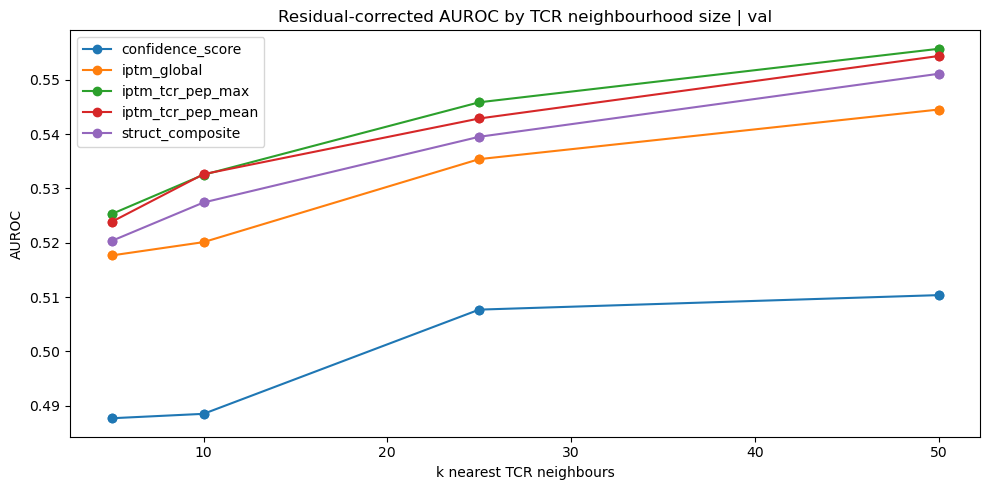

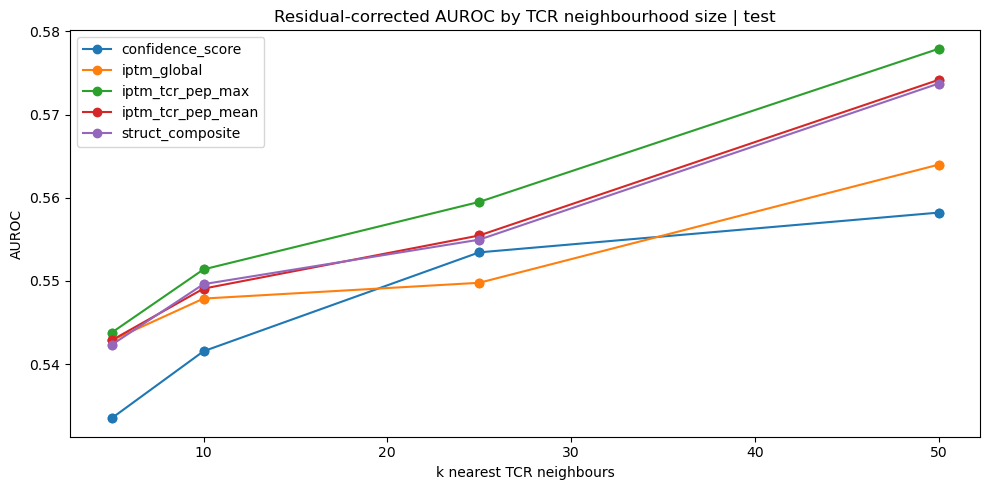

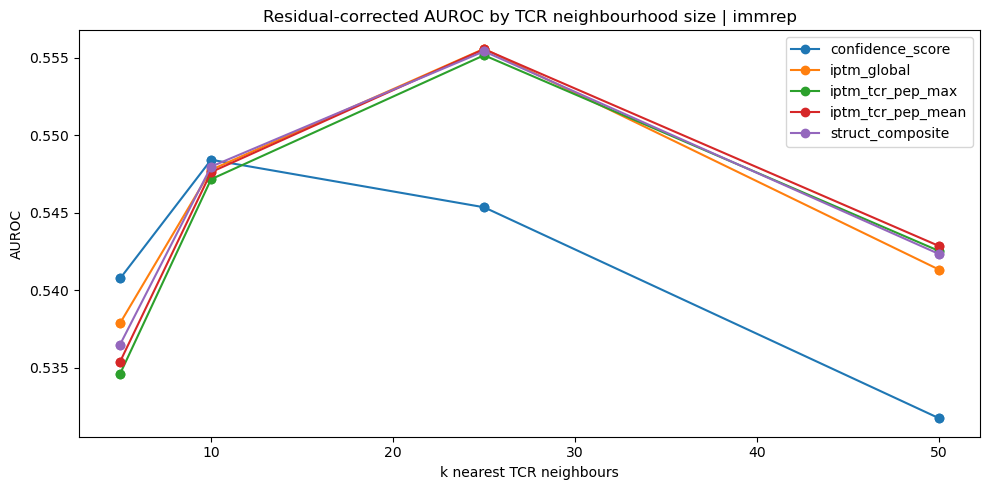

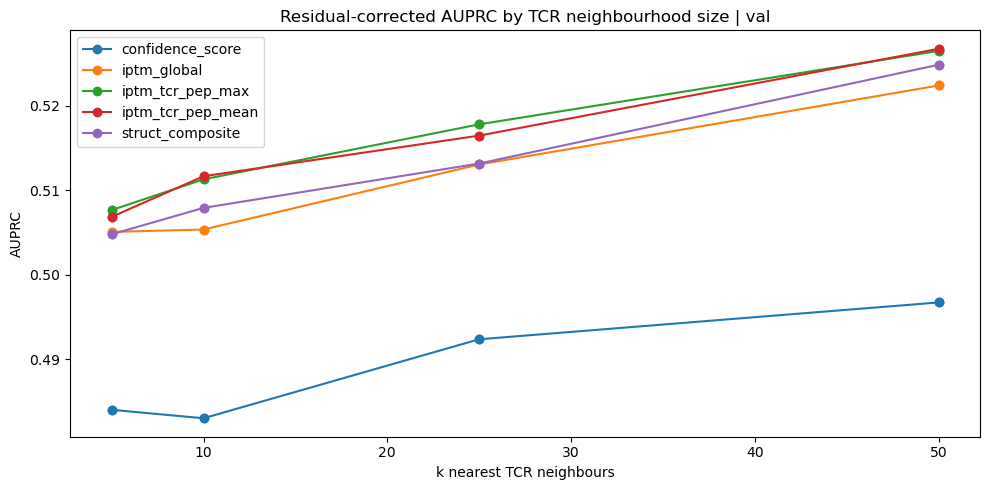

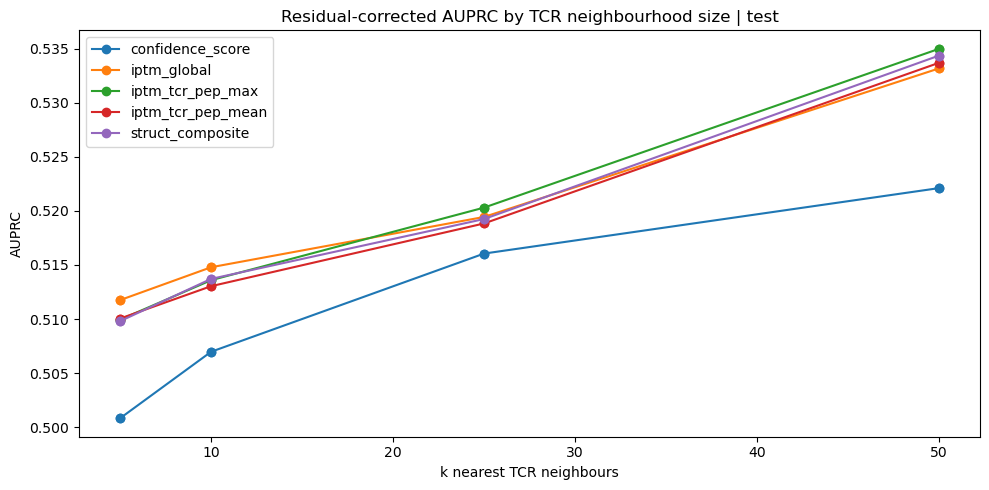

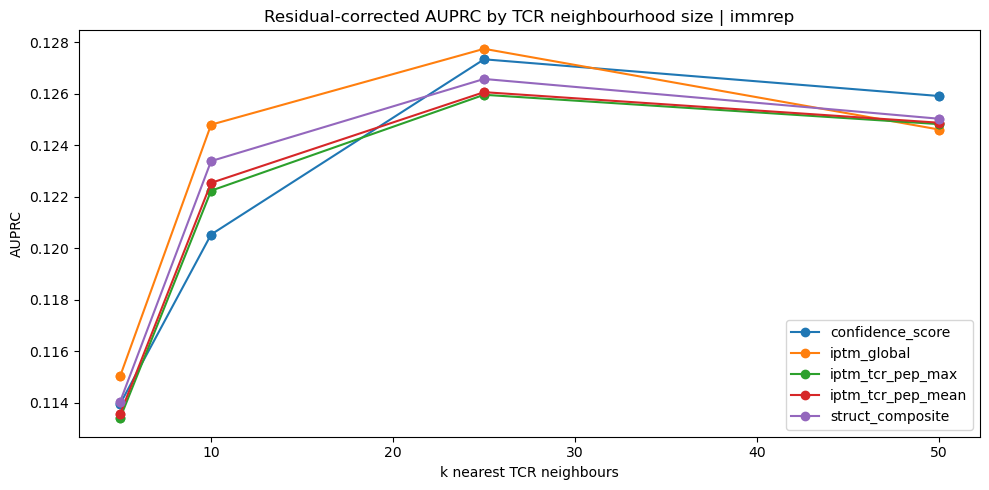

In [26]:
def extract_k(score_col: str):
    m = re.search(r"knn(\d+)", str(score_col))
    return int(m.group(1)) if m else np.nan

if len(auc_df):
    plot_df = auc_df.copy()
    plot_df["k"] = plot_df["score_col"].map(extract_k)
    plot_df["is_residual"] = plot_df["score_col"].str.contains("resid_tcr_pmhc", regex=False)
    plot_df["base_score"] = plot_df["score_col"].str.replace(r"_knn\d+_avg.*$", "", regex=True)

    for split in ["val", "test", "immrep"]:
        g = plot_df[(plot_df["split"] == split) & plot_df["is_residual"] & plot_df["k"].notna()]
        if g.empty:
            continue
        plt.figure(figsize=(10, 5))
        for base_score, gg in g.groupby("base_score"):
            gg = gg.sort_values("k")
            plt.plot(gg["k"], gg["auroc_pos_high"], marker="o", label=base_score)
        plt.title(f"Residual-corrected AUROC by TCR neighbourhood size | {split}")
        plt.xlabel("k nearest TCR neighbours")
        plt.ylabel("AUROC")
        plt.legend()
        plt.tight_layout()
        plt.show()

    for split in ["val", "test", "immrep"]:
        g = plot_df[(plot_df["split"] == split) & plot_df["is_residual"] & plot_df["k"].notna()]
        if g.empty:
            continue
        plt.figure(figsize=(10, 5))
        for base_score, gg in g.groupby("base_score"):
            gg = gg.sort_values("k")
            plt.plot(gg["k"], gg["auprc_pos_high"], marker="o", label=base_score)
        plt.title(f"Residual-corrected AUPRC by TCR neighbourhood size | {split}")
        plt.xlabel("k nearest TCR neighbours")
        plt.ylabel("AUPRC")
        plt.legend()
        plt.tight_layout()
        plt.show()

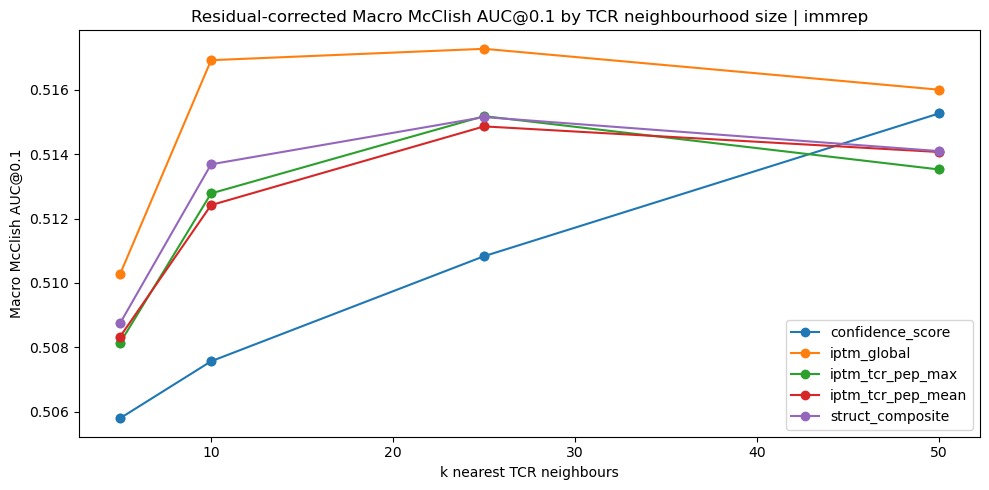

In [27]:
# IMMREP: Macro McClish AUC@0.1 (partial, peptide-macro) for residual-corrected scores.
# Uses the same base_score legend as the global AUROC/AUPRC plots above.
if "macro_auc01_df" in globals() and len(macro_auc01_df):
    mc_plot_df = macro_auc01_df.copy()
    mc_plot_df["k"] = mc_plot_df["score_col"].map(extract_k)
    mc_plot_df["is_residual"] = mc_plot_df["score_col"].str.contains("resid_tcr_pmhc", regex=False)
    mc_plot_df["base_score"] = mc_plot_df["score_col"].str.replace(r"_knn\d+_avg.*$", "", regex=True)

    split = "immrep"
    g = mc_plot_df[
        (mc_plot_df["split"].astype(str).str.lower() == split)
        & mc_plot_df["is_residual"]
        & mc_plot_df["k"].notna()
    ]
    if g.empty:
        print(f"No residual McClish rows for split={split!r}")
    else:
        plt.figure(figsize=(10, 5))
        for base_score, gg in g.groupby("base_score"):
            gg = gg.sort_values("k")
            plt.plot(gg["k"], gg["macro_mcclish_auc01"], marker="o", label=base_score)
        plt.title(
            f"Residual-corrected Macro McClish AUC@0.1 by TCR neighbourhood size | {split}"
        )
        plt.xlabel("k nearest TCR neighbours")
        plt.ylabel("Macro McClish AUC@0.1")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("macro_auc01_df not available; run the Macro AUC0.1 evaluation cell first.")

## 10. ROC and PR curves for selected scores

Set `SELECTED_SCORE_COLS` to the specific columns you want to compare. The default cell tries to select raw `iptm_tcr_pep_mean`, raw `struct_composite`, and their best residual-corrected equivalents.

In [20]:
def best_residual_score_for_base(auc_df: pd.DataFrame, split: str, base: str) -> Optional[str]:
    g = auc_df[
        (auc_df["split"] == split)
        & (auc_df["score_col"].str.startswith(base + "_knn"))
        & (auc_df["score_col"].str.contains("resid_tcr_pmhc", regex=False))
    ].copy()
    if g.empty:
        return None
    return g.sort_values("auroc_pos_high", ascending=False).iloc[0]["score_col"]

# Choose columns based on validation, but inspect them on test and IMMREP.
SELECTED_SCORE_COLS = ["iptm_tcr_pep_mean", "struct_composite"]
for base in ["iptm_tcr_pep_mean", "struct_composite"]:
    best = best_residual_score_for_base(auc_df, "val", base) if len(auc_df) else None
    if best:
        SELECTED_SCORE_COLS.append(best)

SELECTED_SCORE_COLS = [c for c in dict.fromkeys(SELECTED_SCORE_COLS) if c in predictions_df.columns]
print("Selected score columns:")
for c in SELECTED_SCORE_COLS:
    print(" -", c)

Selected score columns:
 - iptm_tcr_pep_mean
 - struct_composite
 - iptm_tcr_pep_mean_knn50_avg_resid_tcr_pmhc
 - struct_composite_knn50_avg_resid_tcr_pmhc


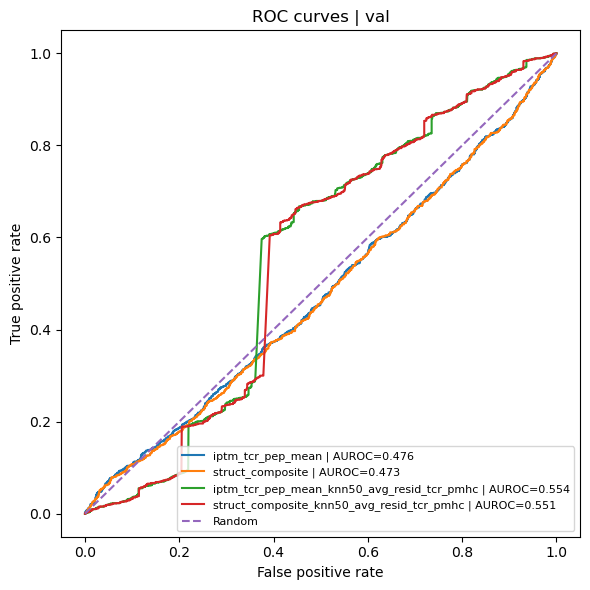

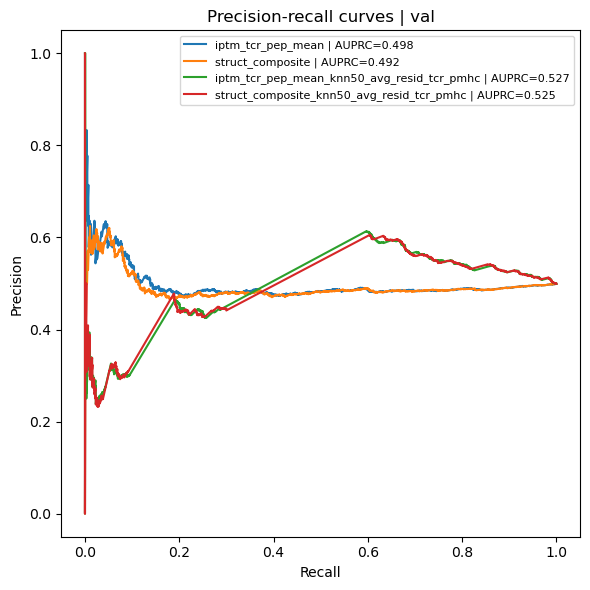

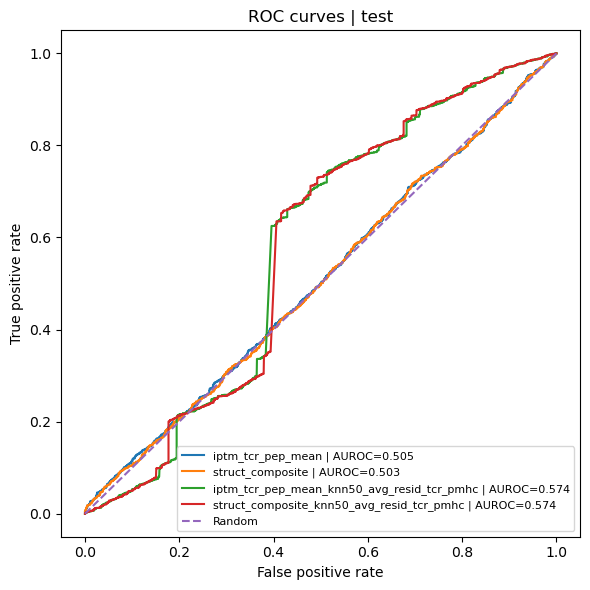

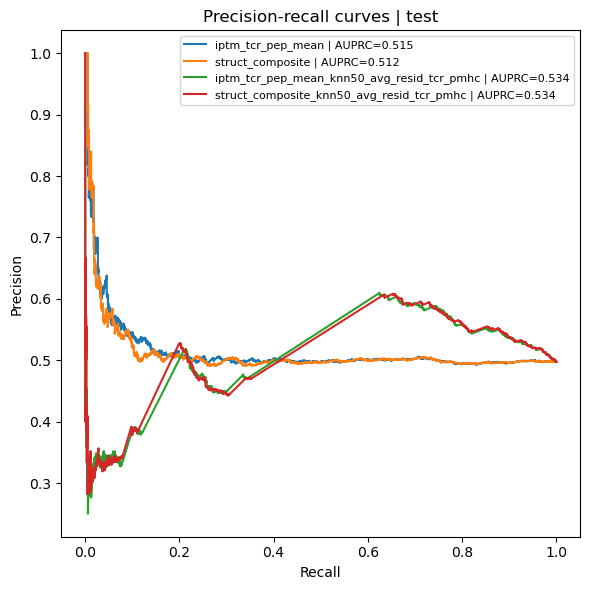

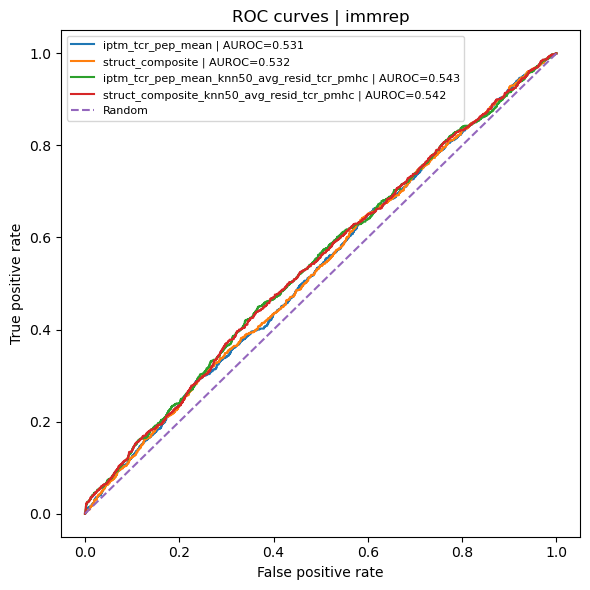

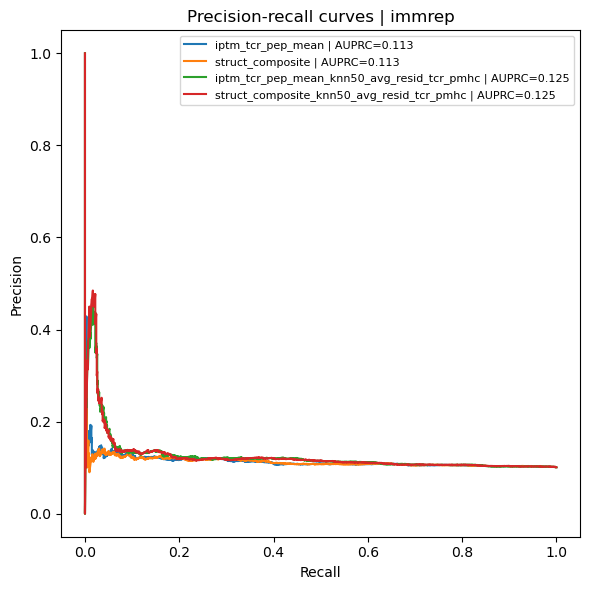

In [21]:
def plot_roc_curves(df: pd.DataFrame, split: str, score_cols: Sequence[str]):
    g = df[df["split"] == split].copy()
    if g.empty or "binding_flag" not in g.columns:
        return
    y_all = pd.to_numeric(g["binding_flag"], errors="coerce")

    plt.figure(figsize=(6, 6))
    plotted = False
    for col in score_cols:
        if col not in g.columns:
            continue
        s = pd.to_numeric(g[col], errors="coerce")
        valid = y_all.notna() & s.notna()
        if valid.sum() < 2 or y_all.loc[valid].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(y_all.loc[valid].astype(int), s.loc[valid].astype(float))
        auc = roc_auc_score(y_all.loc[valid].astype(int), s.loc[valid].astype(float))
        plt.plot(fpr, tpr, label=f"{col} | AUROC={auc:.3f}")
        plotted = True
    if plotted:
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.title(f"ROC curves | {split}")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


def plot_pr_curves(df: pd.DataFrame, split: str, score_cols: Sequence[str]):
    g = df[df["split"] == split].copy()
    if g.empty or "binding_flag" not in g.columns:
        return
    y_all = pd.to_numeric(g["binding_flag"], errors="coerce")

    plt.figure(figsize=(6, 6))
    plotted = False
    for col in score_cols:
        if col not in g.columns:
            continue
        s = pd.to_numeric(g[col], errors="coerce")
        valid = y_all.notna() & s.notna()
        if valid.sum() < 2 or y_all.loc[valid].nunique() < 2:
            continue
        precision, recall, _ = precision_recall_curve(y_all.loc[valid].astype(int), s.loc[valid].astype(float))
        auprc = average_precision_score(y_all.loc[valid].astype(int), s.loc[valid].astype(float))
        plt.plot(recall, precision, label=f"{col} | AUPRC={auprc:.3f}")
        plotted = True
    if plotted:
        plt.title(f"Precision-recall curves | {split}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

for split in ["val", "test", "immrep"]:
    plot_roc_curves(predictions_df, split, SELECTED_SCORE_COLS)
    plot_pr_curves(predictions_df, split, SELECTED_SCORE_COLS)

## 11. Positive versus negative score distributions after transformation

This shows whether the final Bradley-style residual scores separate positives from negatives, and whether the result is driven by a few outliers or a broader distributional shift.

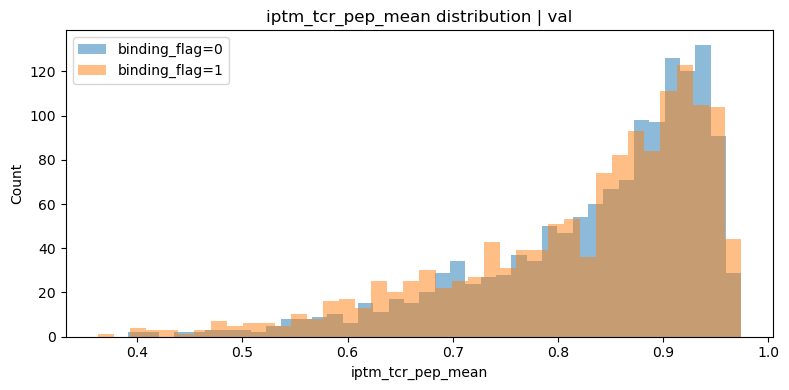

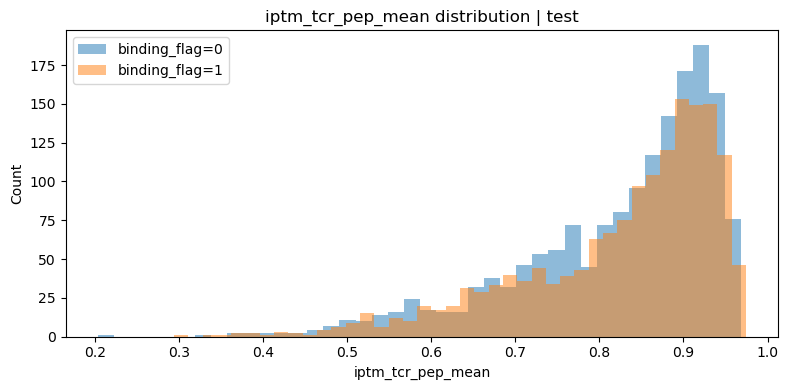

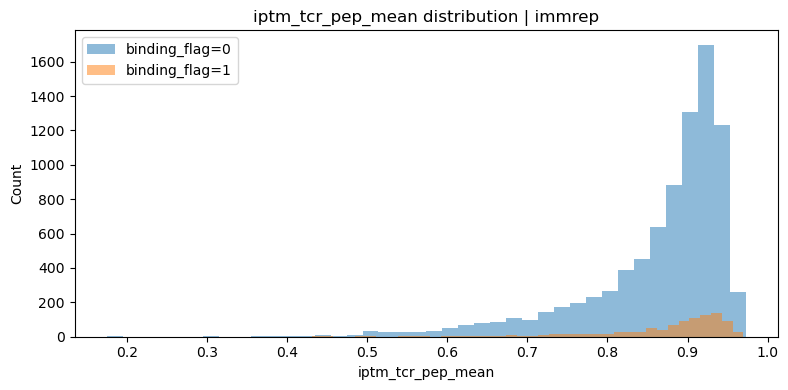

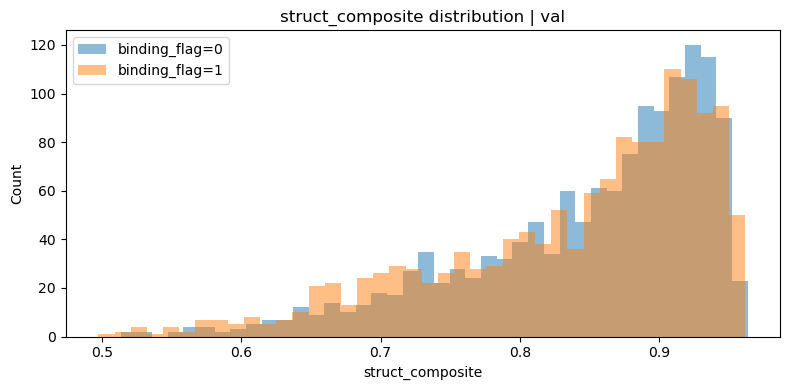

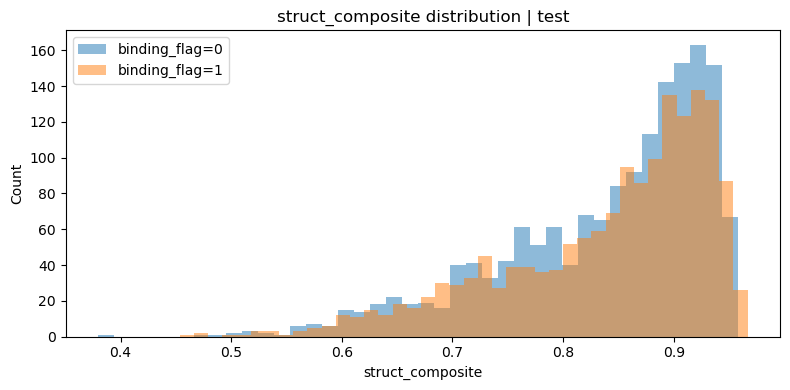

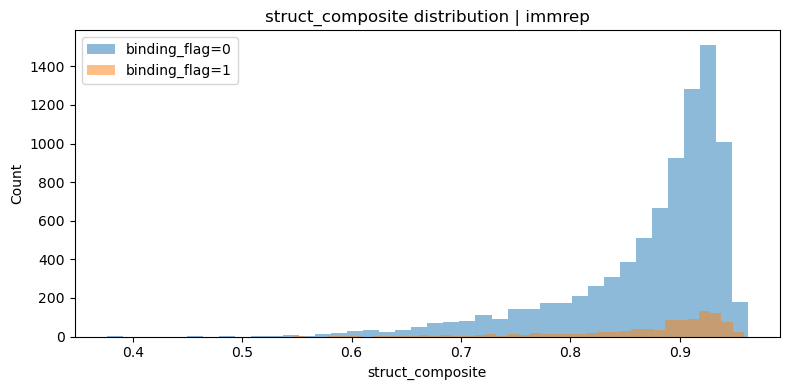

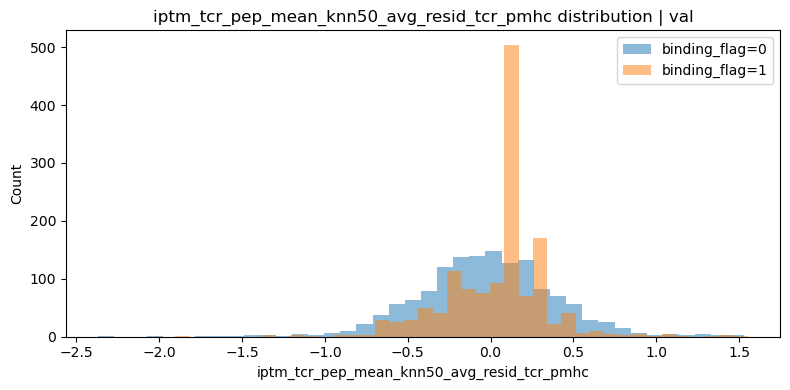

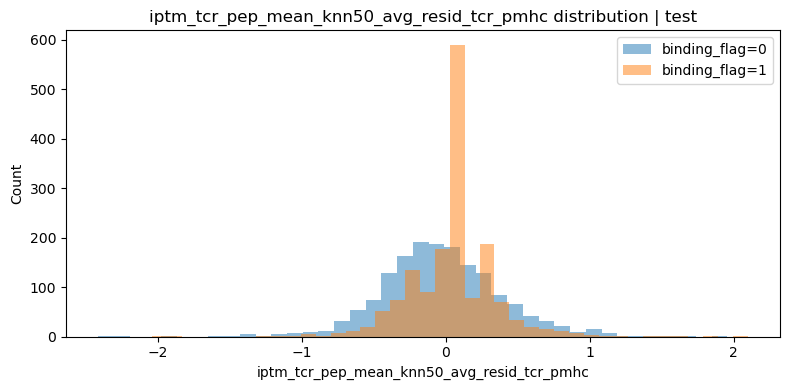

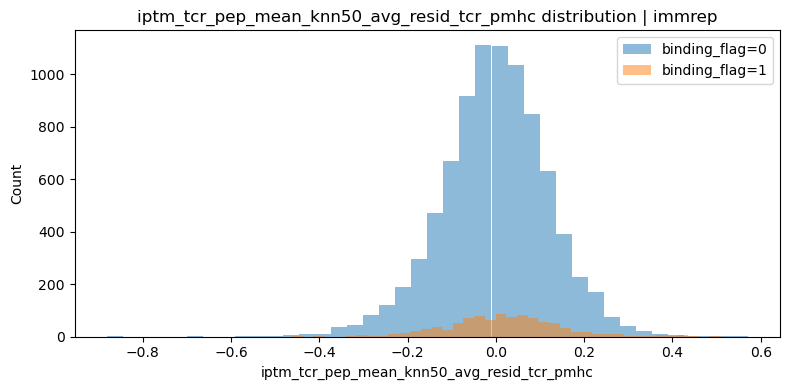

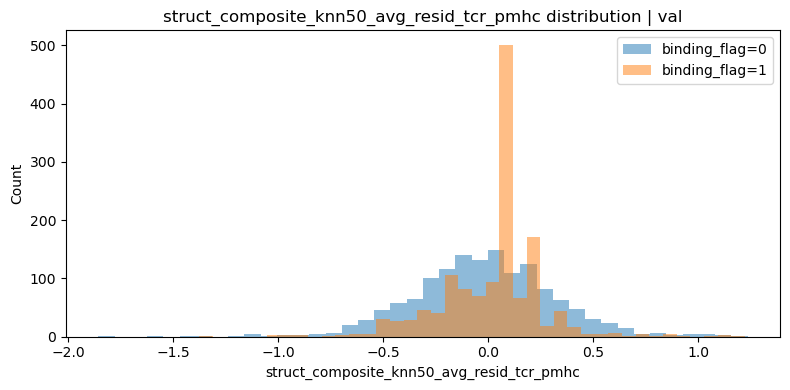

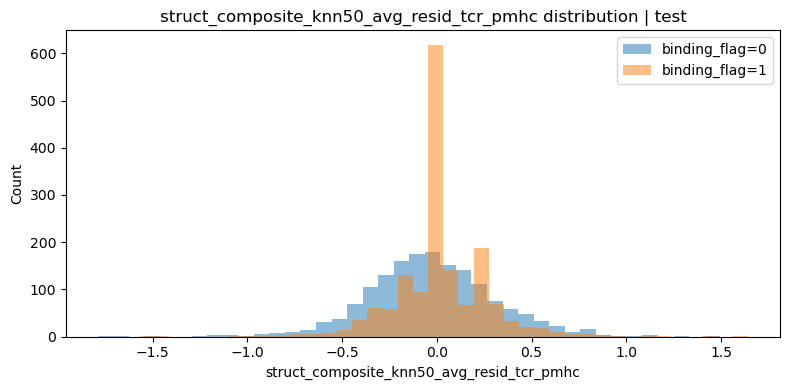

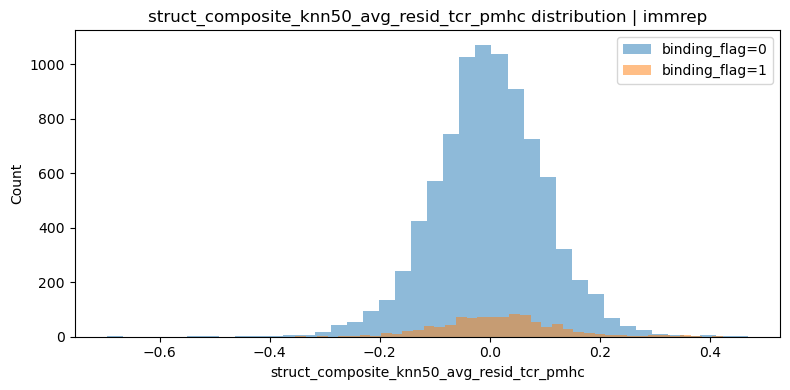

In [22]:
for col in SELECTED_SCORE_COLS:
    plot_score_histograms(predictions_df, col)

## 12. Raw score versus residual-corrected score

Use this to understand what the two-way correction is doing. A large change means the raw score was strongly affected by TCR-level or pMHC-level biases.

In [15]:
def plot_raw_vs_residual(df: pd.DataFrame, split: str, raw_col: str, residual_col: str):
    g = df[df["split"] == split].copy()
    if raw_col not in g.columns or residual_col not in g.columns:
        return
    y = pd.to_numeric(g.get("binding_flag"), errors="coerce") if "binding_flag" in g.columns else pd.Series(np.nan, index=g.index)
    x = pd.to_numeric(g[raw_col], errors="coerce")
    z = pd.to_numeric(g[residual_col], errors="coerce")
    valid = x.notna() & z.notna()
    if valid.sum() == 0:
        return

    plt.figure(figsize=(6, 5))
    for label in sorted(y.loc[valid].dropna().unique()):
        mask = valid & (y == label)
        plt.scatter(x.loc[mask], z.loc[mask], s=12, alpha=0.6, label=f"binding_flag={int(label)}")
    if y.loc[valid].dropna().empty:
        plt.scatter(x.loc[valid], z.loc[valid], s=12, alpha=0.6)
    plt.title(f"Raw versus residual score | {split}")
    plt.xlabel(raw_col)
    plt.ylabel(residual_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

for split in ["val", "test", "immrep"]:
    for raw_col in ["iptm_tcr_pep_mean", "struct_composite"]:
        residual_col = best_residual_score_for_base(auc_df, "val", raw_col) if len(auc_df) else None
        if residual_col:
            plot_raw_vs_residual(predictions_df, split, raw_col, residual_col)

NameError: name 'auc_df' is not defined

## 13. Neighbourhood diagnostics

For k-nearest neighbours, the neighbourhood size should usually equal `k` unless there are fewer unique TCRs than `k`. This section is mostly a check that the TCR neighbourhood construction behaved as expected.

,split,neighbourhood,base_score,tcr_id,n_neighbours,neighbours
0,val,knn5,iptm_tcr_pep_mean,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAILPAGGGKLIFGQGTELSVKPNEPEVTQTPSHQVTQMGQEVILRCVPISNHLYFYWYRQILGQ...,5,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAILPAGGGKLIFGQGTELSVKPNEPEVTQTPSHQVTQMGQEVILRCVPISNHLYFYWYRQILGQ...
1,val,knn5,iptm_tcr_pep_mean,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAIPNYGGSQGNLIFGKGTKLSVKPNDVKVTQSSRYLVKRTGEKVFLECVQDMDHENMFWYRQDP...,5,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAIPNYGGSQGNLIFGKGTKLSVKPNDVKVTQSSRYLVKRTGEKVFLECVQDMDHENMFWYRQDP...
2,val,knn5,iptm_tcr_pep_mean,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAMGGTSYGKLTFGQGTILTVHPNEAGVTQFPSHSVIEKGQTVTLRCDPISGHDNLYWYRRVMGK...,5,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAMGGTSYGKLTFGQGTILTVHPNEAGVTQFPSHSVIEKGQTVTLRCDPISGHDNLYWYRRVMGK...
3,val,knn5,iptm_tcr_pep_mean,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAMKSGGFKTIFGAGTRLFVKANGAGVSQTPSNKVTEKGKYVELRCDPISGHTALYWYRQSLGQG...,5,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAMKSGGFKTIFGAGTRLFVKANGAGVSQTPSNKVTEKGKYVELRCDPISGHTALYWYRQSLGQG...
4,val,knn5,iptm_tcr_pep_mean,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAMREASASGGSYIPTFGRGTSLIVHPYDVKVTQSSRYLVKRTGEKVFLECVQDMDHENMFWYRQ...,5,AQKITQTQPGMFVQEKEAVTLDCTYDTSDPSYGLFWYKQPSSGEMIFLIYQGSYDQQNATEGRYSLNFQKARKSANLVISASQLGDSAMYFCAMREASASGGSYIPTFGRGTSLIVHPYDVKVTQSSRYLVKRTGEKVFLECVQDMDHENMFWYRQ...


count  mean  std   min   25%   50%   75%   max
split  neighbourhood base_score                                                        
immrep knn10         confidence_score   1000.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_global        1000.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_tcr_pep_max   1000.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_tcr_pep_mean  1000.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     struct_composite   1000.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
       knn25         confidence_score   1000.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     iptm_global        1000.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     iptm_tcr_pep_max   1000.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     iptm_tcr_pep_mean  1000.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     struct_composite   1000.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
       knn5          confidence_score   1000.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     iptm_global        1000.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     iptm_tcr_pep_max   1000.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     iptm_tcr_pep_mean  1000.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     struct_composite   1000.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
       knn50         confidence_score   1000.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     iptm_global        1000.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     iptm_tcr_pep_max   1000.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     iptm_tcr_pep_mean  1000.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     struct_composite   1000.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
test   knn10         confidence_score   1569.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_global        1569.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_tcr_pep_max   1569.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_tcr_pep_mean  1569.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     struct_composite   1569.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
       knn25         confidence_score   1569.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     iptm_global        1569.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     iptm_tcr_pep_max   1569.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     iptm_tcr_pep_mean  1569.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
                     struct_composite   1569.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0
       knn5          confidence_score   1569.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     iptm_global        1569.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     iptm_tcr_pep_max   1569.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     iptm_tcr_pep_mean  1569.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
                     struct_composite   1569.0   5.0  0.0   5.0   5.0   5.0   5.0   5.0
       knn50         confidence_score   1569.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     iptm_global        1569.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     iptm_tcr_pep_max   1569.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     iptm_tcr_pep_mean  1569.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
                     struct_composite   1569.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
val    knn10         confidence_score   1367.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_global        1367.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_tcr_pep_max   1367.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
                     iptm_tcr_pep_mean  1367.0  10.0  0.0  10.0  10.0  10.0  10.0

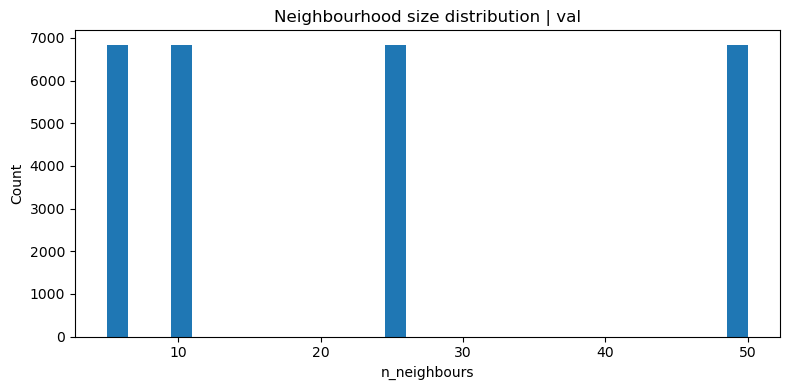

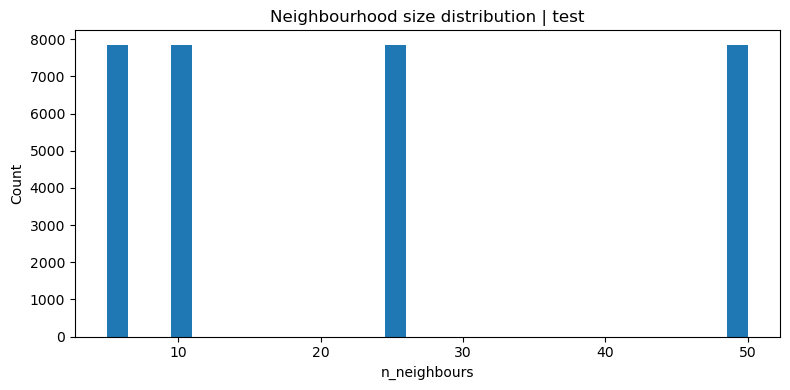

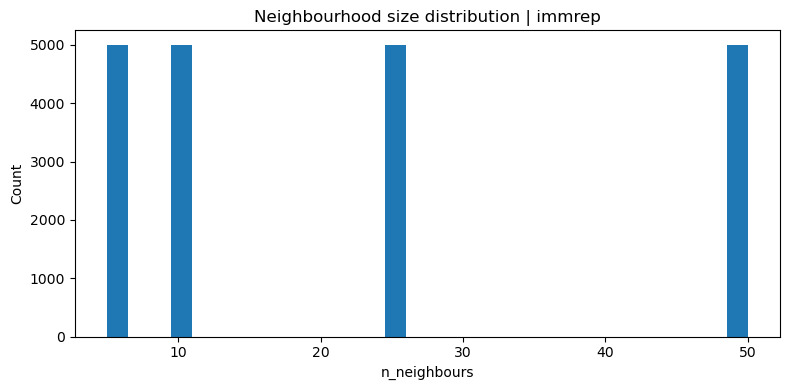

In [25]:
if len(neighbour_df):
    display(neighbour_df.head())
    size_summary = neighbour_df.groupby(["split", "neighbourhood", "base_score"])["n_neighbours"].describe()
    display(size_summary)

    for split in neighbour_df["split"].unique():
        g = neighbour_df[neighbour_df["split"] == split]
        plt.figure(figsize=(8, 4))
        plt.hist(g["n_neighbours"].dropna(), bins=30)
        plt.title(f"Neighbourhood size distribution | {split}")
        plt.xlabel("n_neighbours")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
else:
    print("No neighbourhood dataframe was generated.")

## 14. Optional: validation-calibrated logistic regression

This is not the cleanest baseline because it uses validation labels for calibration. Treat it as a secondary diagnostic. The stronger unsupervised baseline is the raw/transformed structural score evaluated directly.

In [16]:
RUN_LOGREG = True

logreg_df = pd.DataFrame()
if RUN_LOGREG and len(predictions_df):
    # Use raw structural features plus the best validation residual features.
    feature_cols = []
    for c in ["confidence_score", "iptm_global", "iptm_tcr_pep_mean", "iptm_tcr_pep_max", "struct_composite"]:
        if c in predictions_df.columns:
            feature_cols.append(c)

    for base in ["iptm_tcr_pep_mean", "struct_composite"]:
        best = best_residual_score_for_base(auc_df, "val", base) if len(auc_df) else None
        if best and best in predictions_df.columns:
            feature_cols.append(best)

    feature_cols = list(dict.fromkeys(feature_cols))
    feature_cols = [c for c in feature_cols if pd.to_numeric(predictions_df[c], errors="coerce").notna().any()]
    print("Logistic regression features:")
    for c in feature_cols:
        print(" -", c)

    if feature_cols:
        logreg_df = fit_val_logreg_and_eval(predictions_df, feature_cols)
        display(logreg_df)
        if len(logreg_df):
            auc_with_logreg_df = pd.concat([auc_df, logreg_df], ignore_index=True)
            auc_with_logreg_df.to_csv(OUTDIR / "boltz_structural_neighbour_auc_summary_with_logreg.csv", index=False)
else:
    print("Skipping logistic regression.")

NameError: name 'predictions_df' is not defined

## 15. Save final tables

The three most important outputs are:

- `boltz_structural_neighbour_predictions.csv`: one row per retained pair, with raw and transformed scores.
- `boltz_structural_neighbour_auc_summary.csv`: AUROC/AUPRC summary for each score.
- `boltz_structural_neighbour_coverage.csv`: retention after full-chain and high-confidence filters.

In [27]:
predictions_df.to_csv(OUTDIR / "boltz_structural_neighbour_predictions.csv", index=False)
auc_df.to_csv(OUTDIR / "boltz_structural_neighbour_auc_summary.csv", index=False)
coverage_df.to_csv(OUTDIR / "boltz_structural_neighbour_coverage.csv", index=False)
if len(neighbour_df):
    neighbour_df.to_csv(OUTDIR / "boltz_structural_neighbourhoods.csv", index=False)

# Save IMMREP-compatible Macro AUC0.1 outputs if the previous cell has been run.
if "macro_auc01_df" in globals() and len(macro_auc01_df):
    macro_auc01_df.to_csv(OUTDIR / "macro_mcclish_auc01_summary_all_splits.csv", index=False)
if "peptide_auc01_df" in globals() and len(peptide_auc01_df):
    peptide_auc01_df.to_csv(OUTDIR / "peptide_level_mcclish_auc01_all_splits.csv", index=False)

print("Saved files:")
for p in sorted(OUTDIR.glob("*.csv")):
    print(" -", p)


Saved files:
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/boltz_structural_high_conf_raw_scores.csv
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/boltz_structural_neighbour_auc_summary.csv
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/boltz_structural_neighbour_auc_summary_with_logreg.csv
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/boltz_structural_neighbour_coverage.csv
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/boltz_structural_neighbour_predictions.csv
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/boltz_structural_neighbourhoods.csv
 - /home/natasha/multimodal_model/scripts/analysis/boltz_structural_neighbour_classifier_notebook/macro_mcclish_auc01_summary_all_splits.csv

## 16. Suggested interpretation template

Use this only after inspecting the tables and plots.

A defensible wording would be:

> We evaluated a structure-only Boltz baseline on full-chain TCR–pMHC complexes for which Boltz returned high-confidence predictions (`confidence_score >= 0.8`). For each retained pair, we extracted global confidence metrics and interface-specific pairwise ipTM scores, with particular focus on the TCR–peptide interface. We then constructed a TCR × pMHC score matrix and applied a Bradley-style transformation: peptide score vectors were averaged over local neighbourhoods of similar TCRs, defined by normalised Levenshtein distance, and corrected for TCR-specific and pMHC-specific confidence biases by subtracting row and column means and adding back the global mean. Performance was evaluated using AUROC and AUPRC on validation, test and IMMREP.

The main caveat is coverage: the claim is about the retained high-confidence structural subset, not necessarily the full dataset. If the residual score improves over raw confidence and raw ipTM, the stronger conclusion is that Boltz contains pair-specific structural compatibility signal rather than only generic confidence signal.